# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Import the libraries you will be using for analysis
!pip install numpy==1.26.4 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2

In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Try loading one file

df = pd.read_parquet('/content/drive/MyDrive/IIITB_Course/Assignment_1/Datasets_and_Dictionary_nyc/trip_records/2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

In [6]:
df.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [7]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [8]:
# from google.colab import drive
# drive.mount('/content/drive')

In [9]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/content/drive/MyDrive/IIITB_Course/Assignment_1/Datasets_and_Dictionary_nyc/trip_records')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
sample_data = []
# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        curr_month_file = pd.read_parquet(file_path)

        curr_month_file['tpep_pickup_datetime'] = pd.to_datetime(curr_month_file['tpep_pickup_datetime'])

        curr_month_file['pickup_date'] = curr_month_file['tpep_pickup_datetime'].dt.date
        curr_month_file['pickup_hour'] = curr_month_file['tpep_pickup_datetime'].dt.hour

        sample = (
                curr_month_file.groupby(['pickup_date', 'pickup_hour'], group_keys=False)
                .apply(lambda x: x.sample(frac = 0.007, random_state = 42))
              )
        sample_data.append(sample)
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

df = pd.concat(sample_data, ignore_index=True)
df.drop(columns=['pickup_date', 'pickup_hour'], inplace=True)

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [10]:
# Store the df in csv/parquet
# df.to_parquet('')
df.to_parquet('/content/drive/MyDrive/IIITB_Course/Assignment_1/Datasets_and_Dictionary_nyc/sample_fraq_taxi__data.parquet')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [11]:
# Load the new data file
df = pd.read_parquet('/content/drive/MyDrive/IIITB_Course/Assignment_1/Datasets_and_Dictionary_nyc/sample_fraq_taxi__data.parquet')

In [12]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,2,2023-09-01 00:39:59,2023-09-01 01:00:28,NaN,4.71,NaN,None,113,238,0,24.83,0.0,0.5,4.32,0.00,1.0,33.15,NaN,NaN,NaN
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,5.10,1.0,0.5,0.00,0.00,1.0,10.10,2.5,0.00,NaN
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,70.00,0.0,0.5,15.71,6.94,1.0,98.40,2.5,1.75,NaN
3,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,59.70,1.0,0.5,0.00,0.00,1.0,64.70,2.5,0.00,NaN
4,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1.0,0.71,1.0,N,144,232,1,7.90,1.0,0.5,2.00,0.00,1.0,14.90,2.5,0.00,NaN


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265487 entries, 0 to 265486
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               265487 non-null  int64         
 1   tpep_pickup_datetime   265487 non-null  datetime64[us]
 2   tpep_dropoff_datetime  265487 non-null  datetime64[us]
 3   passenger_count        256656 non-null  float64       
 4   trip_distance          265487 non-null  float64       
 5   RatecodeID             256656 non-null  float64       
 6   store_and_fwd_flag     256656 non-null  object        
 7   PULocationID           265487 non-null  int64         
 8   DOLocationID           265487 non-null  int64         
 9   payment_type           265487 non-null  int64         
 10  fare_amount            265487 non-null  float64       
 11  extra                  265487 non-null  float64       
 12  mta_tax                265487 non-null  floa

In [14]:
df.shape

(265487, 20)

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [15]:
# Fix the index and drop any columns that are not needed
df.reset_index(drop=True, inplace=True)

In [16]:
df['store_and_fwd_flag'].value_counts(dropna=False)

,count
store_and_fwd_flag,
N,255146
None,8831
Y,1510


In [17]:
print("""
store_and_fwd_flag column only indicate whether trip data was stored before being send to the vendor.
since column is not required for analysis, it can be dropped.
""")


store_and_fwd_flag column only indicate whether trip data was stored before being send to the vendor.
since column is not required for analysis, it can be dropped.



In [18]:
# drop store_and_fwd_flag column
df = df.drop(columns=['store_and_fwd_flag'])

In [19]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,2,2023-09-01 00:39:59,2023-09-01 01:00:28,NaN,4.71,NaN,113,238,0,24.83,0.0,0.5,4.32,0.00,1.0,33.15,NaN,NaN,NaN
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,142,142,2,5.10,1.0,0.5,0.00,0.00,1.0,10.10,2.5,0.00,NaN
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,132,163,1,70.00,0.0,0.5,15.71,6.94,1.0,98.40,2.5,1.75,NaN
3,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,249,180,4,59.70,1.0,0.5,0.00,0.00,1.0,64.70,2.5,0.00,NaN
4,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1.0,0.71,1.0,144,232,1,7.90,1.0,0.5,2.00,0.00,1.0,14.90,2.5,0.00,NaN


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [20]:
# Combine the two airport fee columns
df.columns


Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'Airport_fee', 'airport_fee'],
      dtype='object')

In [21]:
df[['airport_fee', 'Airport_fee']]

,airport_fee,Airport_fee
0,NaN,NaN
1,NaN,0.00
2,NaN,1.75
3,NaN,0.00
4,NaN,0.00
...,...,...
265482,NaN,0.00
265483,NaN,0.00
265484,NaN,0.00
265485,NaN,NaN


In [22]:
# Check missing vales counts to understand whether it's naming error or not
airport_col_null = ((df['airport_fee'].isna()) & (df['Airport_fee'].notna())).sum()
Airport_col_null = ((df['airport_fee'].notna()) & (df['Airport_fee'].isna())).sum()
both_null = ((df['airport_fee'].isna()) & (df['Airport_fee'].isna())).sum()
both_col_notnull = ((df['airport_fee'].notna()) & (df['Airport_fee'].notna())).sum()

print(airport_col_null, Airport_col_null, both_null, both_col_notnull)

235874 20782 8831 0


### We can Combine both columns since both_col_notnull = 0 so it's naming error.
---

In [23]:
df['airport_fee_combined'] = df['airport_fee'].fillna(df['Airport_fee'])
df['airport_fee'] = df['airport_fee_combined']
df = df.drop(columns = ['airport_fee_combined', 'Airport_fee'])

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [24]:
# check where values of fare amount are negative

monetory_colmns = [
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'airport_fee'
]

In [25]:
neg_cols = (df[monetory_colmns] < 0).sum().sort_values(ascending=False)
neg_cols

,0
mta_tax,11
improvement_surcharge,11
total_amount,11
congestion_surcharge,6
airport_fee,2
extra,1
fare_amount,0
tip_amount,0
tolls_amount,0


In [26]:
df[monetory_colmns] = df[monetory_colmns].clip(lower=0)

In [27]:
(df[monetory_colmns] < 0).sum()

,0
fare_amount,0
extra,0
mta_tax,0
tip_amount,0
tolls_amount,0
improvement_surcharge,0
total_amount,0
congestion_surcharge,0
airport_fee,0


Did you notice something different in the `RatecodeID` column for above records?

In [28]:
# Analyse RatecodeID for the negative fare amounts

df[df['fare_amount'] < 0]['RatecodeID']

,RatecodeID


In [29]:
print("""
After clipping negative monetary values to 0. There are no remaining negative fare_amount records.
Hence, RatecodeID analysis for negative fare_amount returns no records.
""")


After clipping negative monetary values to 0. There are no remaining negative fare_amount records.
Hence, RatecodeID analysis for negative fare_amount returns no records.



In [30]:
# Find which columns have negative values
numerical_columns = df.select_dtypes(include='number')

negative_columns = (numerical_columns < 0).sum().sort_values(ascending=False)
negative_columns

,0
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0
extra,0
mta_tax,0


In [31]:
# fix these negative values

# No negative col remain after fixing monetary columns
negative_columns[negative_columns > 0]

,0


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [32]:
# Find the proportion of missing values in each column

missing_val_columns = df.isna().columns

missing_val_proportion = (df[missing_val_columns].isna().mean().mul(100)
                            .sort_values(ascending=False).round(2))

missing_val_proportion

,0
airport_fee,3.33
congestion_surcharge,3.33
passenger_count,3.33
RatecodeID,3.33
extra,0.00
total_amount,0.00
improvement_surcharge,0.00
tolls_amount,0.00
tip_amount,0.00
mta_tax,0.00


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [33]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
df[df['passenger_count'].isna()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-09-01 00:39:59,2023-09-01 01:00:28,NaN,4.71,NaN,113,238,0,24.83,0.0,0.5,4.32,0.0,1.0,33.15,NaN,NaN
43,1,2023-09-01 05:41:17,2023-09-01 05:51:07,NaN,0.00,NaN,143,75,0,14.53,0.0,0.5,0.00,0.0,1.0,18.53,NaN,NaN
72,2,2023-09-01 07:44:46,2023-09-01 07:58:24,NaN,2.57,NaN,224,140,0,17.01,0.0,0.5,0.00,0.0,1.0,21.01,NaN,NaN
126,1,2023-09-01 10:09:37,2023-09-01 10:29:11,NaN,0.00,NaN,48,236,0,25.00,0.0,0.5,4.35,0.0,1.0,35.35,NaN,NaN
170,2,2023-09-01 11:13:50,2023-09-01 11:40:25,NaN,11.33,NaN,25,138,0,36.94,0.0,0.5,7.69,0.0,1.0,46.13,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265437,1,2023-11-30 22:34:27,2023-11-30 22:47:59,NaN,2.50,NaN,114,68,0,15.60,1.0,0.5,4.12,0.0,1.0,24.72,NaN,NaN
265442,2,2023-11-30 23:02:25,2023-11-30 23:17:41,NaN,3.06,NaN,68,231,0,22.85,0.0,0.5,0.00,0.0,1.0,26.85,NaN,NaN
265453,2,2023-11-30 23:37:00,2023-12-01 00:07:00,NaN,7.86,NaN,48,243,0,31.27,0.0,0.5,5.00,0.0,1.0,40.27,NaN,NaN
265473,1,2023-11-30 23:57:07,2023-12-01 00:08:00,NaN,0.00,NaN,161,143,0,11.79,0.0,0.5,0.00,0.0,1.0,15.79,NaN,NaN


In [34]:
print(df['passenger_count'].mean(), df['passenger_count'].mode()[0])

1.3674295555139955 1.0


In [35]:
df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].mode()[0])

In [36]:
df['passenger_count'].isna().sum()

0

Did you find zeroes in passenger_count? Handle these.

In [37]:
passenger_count_mode_val = (df.loc[df['passenger_count'] > 0, 'passenger_count']
                         .mode()[0])
df['passenger_count'] = (df['passenger_count']
                         .replace(0, np.nan)
                         .fillna(passenger_count_mode_val))

In [38]:
df['passenger_count'].value_counts().sort_index()

,count
passenger_count,
1.0,206299
2.0,38669
3.0,9640
4.0,5340
5.0,3300
6.0,2234
7.0,2
8.0,2
9.0,1


**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [39]:
# Fix missing values in 'RatecodeID'
df['RatecodeID'].isna().sum()

8831

In [40]:
df['RatecodeID'].value_counts(dropna=False, ascending=False)

,count
RatecodeID,
1.0,242253
2.0,10081
NaN,8831
99.0,1530
5.0,1428
3.0,845
4.0,519


Since RatecodeID has only 3.42% missing values, missing values are imputed using the mode.

In [41]:
df['RatecodeID'] = df['RatecodeID'].fillna(df['RatecodeID'].mode()[0])

In [42]:
df['RatecodeID'].isna().sum()

0

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [43]:
# handle null values in congestion_surcharge

df['congestion_surcharge'].isna().sum()

8831

In [44]:
df['congestion_surcharge'].value_counts(dropna=False, ascending=False)

,count
congestion_surcharge,
2.5,236938
0.0,19718
NaN,8831


In [45]:
print(df['congestion_surcharge'].mean(), df['congestion_surcharge'].median(), df['congestion_surcharge'].mode()[0])

2.3079335764603206 2.5 2.5


In [46]:
# Since congestion_surcharge has only a few fixed values and 2.5 is the most frequent value,
# missing values are imputed using the mode.

df['congestion_surcharge'] = df['congestion_surcharge'].fillna(df['congestion_surcharge'].mode()[0])

In [47]:
df['congestion_surcharge'].isna().sum()

0

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [48]:
# Handle any remaining missing values

df.isna().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0


In [49]:
df['airport_fee'].head()

,airport_fee
0,NaN
1,0.00
2,1.75
3,0.00
4,0.00


In [50]:
df['airport_fee'].value_counts(dropna=False, ascending=False)

,count
airport_fee,
0.00,234052
1.75,16911
NaN,8831
1.25,5693


In [51]:
print(df['airport_fee'].mean(), df['airport_fee'].median(), df['airport_fee'].mode()[0])

0.14303386634249735 0.0 0.0


In [52]:
# Since airport_fee has a few fixed/discrete values, filling missing values
# with Mode is a reasonable choice

df['airport_fee'] = df['airport_fee'].fillna(df['airport_fee'].mode()[0])

In [53]:
df.isna().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [54]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
df.describe().T


,count,mean,min,25%,50%,75%,max,std
VendorID,265487.0,1.733475,1.0,1.0,2.0,2.0,6.0,0.447562
tpep_pickup_datetime,265487,2023-07-02 20:30:32.375570,2023-01-01 00:04:34,2023-04-02 16:33:43,2023-06-27 16:01:27,2023-10-06 20:06:22.500000,2023-12-31 23:54:03,NaN
tpep_dropoff_datetime,265487,2023-07-02 20:47:54.093198,2023-01-01 00:17:32,2023-04-02 16:55:59.500000,2023-06-27 16:18:21,2023-10-06 20:28:48,2024-01-01 20:14:57,NaN
passenger_count,265487.0,1.370538,1.0,1.0,1.0,1.0,9.0,0.862992
trip_distance,265487.0,3.581805,0.0,1.05,1.8,3.4,22528.82,48.595892
RatecodeID,265487.0,1.636491,1.0,1.0,1.0,1.0,99.0,7.422751
PULocationID,265487.0,165.172668,1.0,132.0,162.0,234.0,265.0,64.070411
DOLocationID,265487.0,163.952988,1.0,113.0,162.0,234.0,265.0,69.77973
payment_type,265487.0,1.16498,0.0,1.0,1.0,1.0,4.0,0.506647
fare_amount,265487.0,19.830154,0.0,9.3,13.5,21.9,910.0,18.204986


In [55]:
# Checking observation min max values in each columns
df_value_range = {}
for col in df.columns:
  df_value_range[col] = [df[col].min(), df[col].max()]

df_value_range

{'VendorID': [1, 6],
 'tpep_pickup_datetime': [Timestamp('2023-01-01 00:04:34'),
  Timestamp('2023-12-31 23:54:03')],
 'tpep_dropoff_datetime': [Timestamp('2023-01-01 00:17:32'),
  Timestamp('2024-01-01 20:14:57')],
 'passenger_count': [1.0, 9.0],
 'trip_distance': [0.0, 22528.82],
 'RatecodeID': [1.0, 99.0],
 'PULocationID': [1, 265],
 'DOLocationID': [1, 265],
 'payment_type': [0, 4],
 'fare_amount': [0.0, 910.0],
 'extra': [0.0, 14.25],
 'mta_tax': [0.0, 0.8],
 'tip_amount': [0.0, 150.29],
 'tolls_amount': [0.0, 143.0],
 'improvement_surcharge': [0.0, 1.0],
 'total_amount': [0.0, 911.0],
 'congestion_surcharge': [0.0, 2.5],
 'airport_fee': [0.0, 1.75]}

In [56]:
numeric_columns = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "extra",
    "mta_tax",
    "improvement_surcharge",
    "tip_amount",
    "tolls_amount",
    "total_amount",
    "congestion_surcharge",
    "airport_fee"
]

In [57]:
# Check lower, middle, upper quantile values

df[numeric_columns].quantile([0.01, 0.25, 0.50, 0.75, 1]).T

,0.01,0.25,0.50,0.75,1.00
passenger_count,1.00,1.00,1.00,1.00,9.00
trip_distance,0.00,1.05,1.80,3.40,22528.82
fare_amount,4.40,9.30,13.50,21.90,910.00
extra,0.00,0.00,1.00,2.50,14.25
mta_tax,0.50,0.50,0.50,0.50,0.80
improvement_surcharge,1.00,1.00,1.00,1.00,1.00
tip_amount,0.00,1.00,2.84,4.42,150.29
tolls_amount,0.00,0.00,0.00,0.00,143.00
total_amount,8.76,15.96,21.02,30.80,911.00
congestion_surcharge,0.00,2.50,2.50,2.50,2.50


In [58]:
# Since 0.75 and 1 quantile range difference too large,
# checking upper-end quantile is required step to understand outliers
df[numeric_columns].quantile([0.90, 0.95, 0.99]).T

,0.90,0.95,0.99
passenger_count,2.00,3.00,5.00
trip_distance,9.09,15.30,20.17
fare_amount,42.20,70.00,77.20
extra,4.25,5.00,7.50
mta_tax,0.50,0.50,0.50
improvement_surcharge,1.00,1.00,1.00
tip_amount,7.56,12.00,17.70
tolls_amount,0.00,6.55,6.94
total_amount,60.15,82.69,103.91
congestion_surcharge,2.50,2.50,2.50


In [59]:
# Select important numeric columns for outlier detection

outlier_cols = [
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'tolls_amount',
    'total_amount'
]

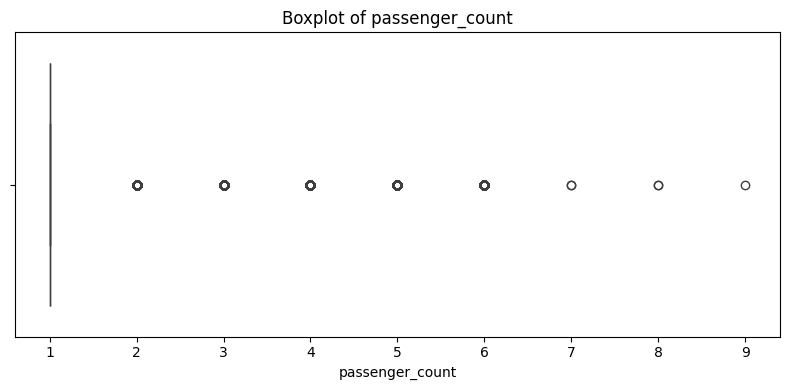

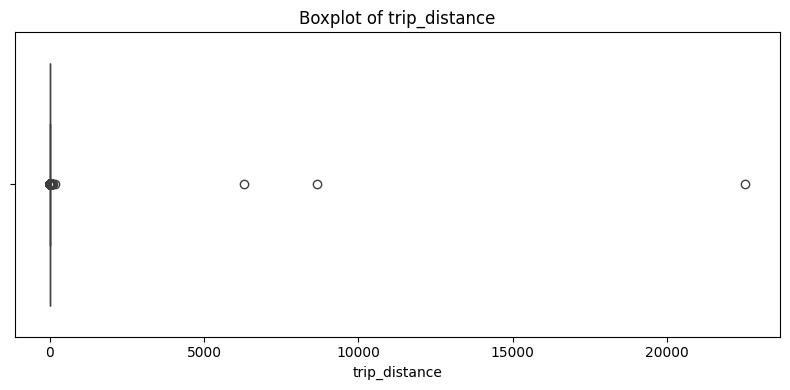

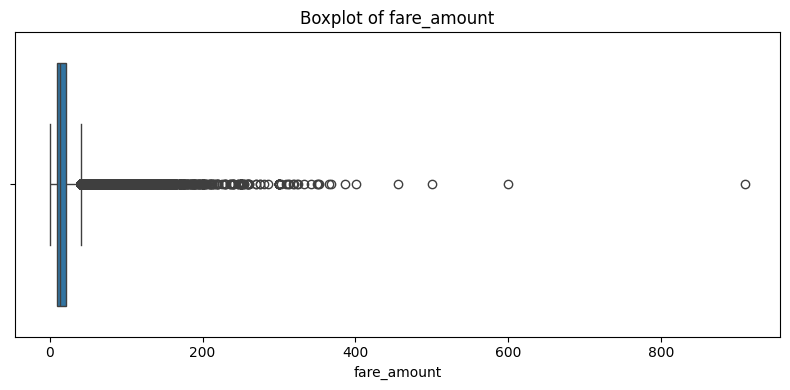

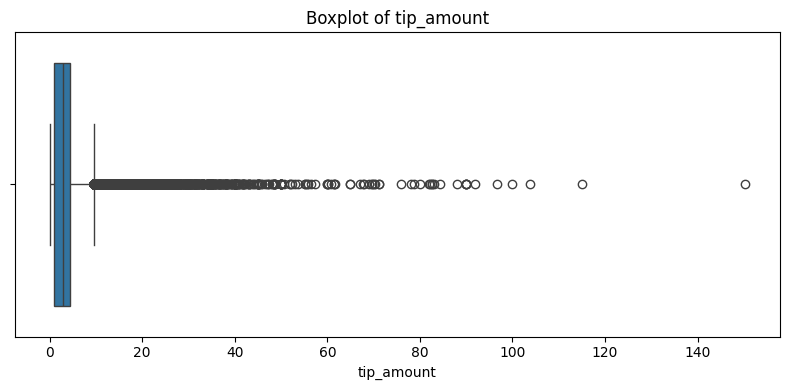

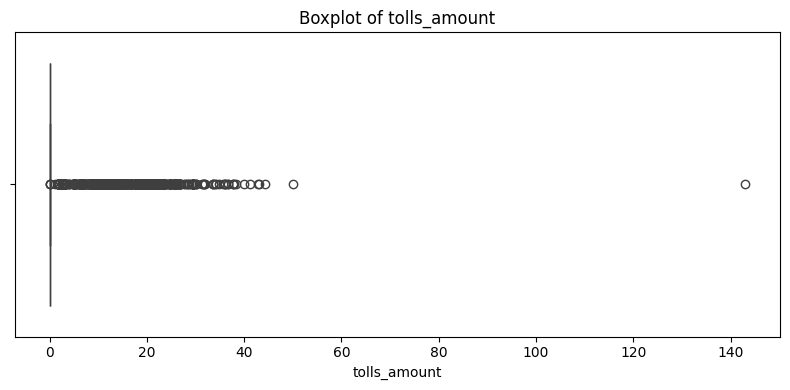

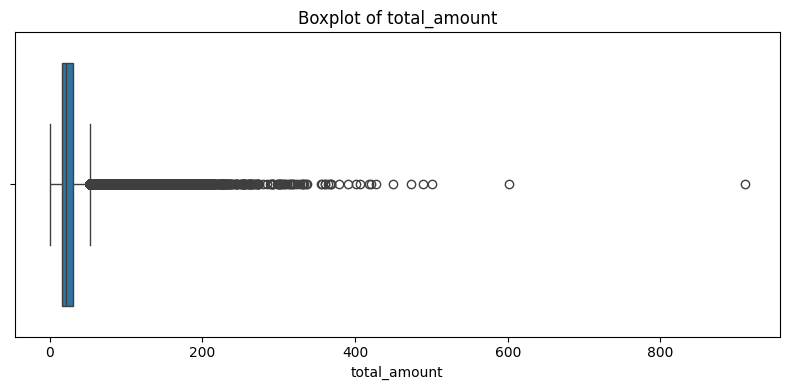

In [60]:
# Visualise the outlier potential using boxplots

for col in outlier_cols:
  plt.figure(figsize=(8, 4))

  sns.boxplot(data=df[col], orient='h')

  plt.title(f'Boxplot of {col}')
  plt.xlabel(col)

  plt.tight_layout()
  plt.show()

In [61]:
# Identify outliers using IQR method

outlier_stats = []

for col in outlier_cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  IQR = q3 - q1

  LB = q1 - 1.5 * IQR
  UB = q3 + 1.5 * IQR

  outlier_cnt = ((df[col] < LB) | (df[col] > UB)).sum()
  outlier_perc = (outlier_cnt / df.shape[0]) * 100

  outlier_stats.append({
      "column": col,
      "Q1": q1,
      "Q3": q3,
      "IQR": IQR,
      "LB": LB,
      "UB": UB,
      "outlier_cnt": outlier_cnt,
      "outlier_perc": outlier_perc
  })

outlier_stats_df = pd.DataFrame(outlier_stats)
outlier_stats_df


,column,Q1,Q3,IQR,LB,UB,outlier_cnt,outlier_perc
0,passenger_count,1.00,1.00,0.00,1.000,1.000,59188,22.294124
1,trip_distance,1.05,3.40,2.35,-2.475,6.925,34713,13.075216
2,fare_amount,9.30,21.90,12.60,-9.600,40.800,27440,10.335723
3,tip_amount,1.00,4.42,3.42,-4.130,9.550,20376,7.674952
4,tolls_amount,0.00,0.00,0.00,0.000,0.000,21483,8.091922
5,total_amount,15.96,30.80,14.84,-6.300,53.060,30566,11.513181


In [62]:
# Check invalid values

valid_ranges = {
    "VendorID": [1, 2],
    "RatecodeID": [1, 2, 3, 4, 5, 6],
    "payment_type": [1, 2, 3, 4, 5, 6],
}

for col, valid_list in valid_ranges.items():
  invalid_rows = df[df[col].notna() & ~df[col].isin(valid_list)]

  print(f"{col}: {valid_list}")
  print(f"row_cnt: {invalid_rows.shape[0]}")
  print(f"unique_values: {df[col].dropna().unique()}")
  print(f"Per: {round((invalid_rows.shape[0] / df.shape[0])* 100, 4)} %")
  print("---------------------")

  if invalid_rows.shape[0] > 0:
    print("Invalid Values")
    print(invalid_rows[col].value_counts().sort_values(ascending=False))
  print("\n")


VendorID: [1, 2]
row_cnt: 64
unique_values: [2 1 6]
Per: 0.0241 %
---------------------
Invalid Values
VendorID
6    64
Name: count, dtype: int64


RatecodeID: [1, 2, 3, 4, 5, 6]
row_cnt: 1530
unique_values: [ 1.  2.  4. 99.  5.  3.]
Per: 0.5763 %
---------------------
Invalid Values
RatecodeID
99.0    1530
Name: count, dtype: int64


payment_type: [1, 2, 3, 4, 5, 6]
row_cnt: 8831
unique_values: [0 2 1 4 3]
Per: 3.3263 %
---------------------
Invalid Values
payment_type
0    8831
Name: count, dtype: int64




**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [63]:
pre_passenger_cnt_removal = df.shape[0]

In [64]:
# remove passenger_count > 6
print(df[df['passenger_count'] > 6].shape[0], len(df['passenger_count']))

5 265487


In [65]:
df = df[df['passenger_count'] <= 6].copy()

In [66]:
post_passenger_cnt_removal = df.shape[0]

In [67]:
print(df[df['passenger_count'] > 6].shape[0], len(df['passenger_count']))

0 265482


In [68]:
pre_passenger_cnt_removal - post_passenger_cnt_removal

5

In [69]:
# Continue with outlier handling
valid_ratecode_ids = valid_ranges['RatecodeID']
valid_vendor_ids =  valid_ranges['VendorID']
valid_payment_types = valid_ranges['payment_type']

# 1 - Entries where trip_distance is nearly 0 and fare_amount is more than 300
trip_dist_near_zero_high_fare = ((df['trip_distance'] <= 0.1) &
                                 (df['fare_amount'] > 300))

# 2 - Entries where trip_distance and fare_amount are 0 but the pickup
# and dropoff zones are different (both distance and fare
# should not be zero for different zones)
trip_fare_zero_zone_diff = ((df['trip_distance'] == 0) &
                            (df['fare_amount'] == 0) &
                            (df['PULocationID'] != df['DOLocationID']))

# 3 - Entries where trip_distance is more than 250 miles.
trip_dist_gt_250 = df['trip_distance'] > 250

# 4 - Entries where payment_type is 0 (there is no payment_type 0
# defined in the data dictionary)
payment_type_outlier = ~df['payment_type'].isin(valid_payment_types)

# 5 - Handle VendorID outlier
vendor_id_outlier = ~df['VendorID'].isin(valid_vendor_ids)

# 6 - Handle RateCodeID outlier
rate_code_outlier = ~df['RatecodeID'].isin(valid_ratecode_ids)

outlier_rows = (trip_dist_near_zero_high_fare |
                 trip_fare_zero_zone_diff |
                 trip_dist_gt_250 |
                 payment_type_outlier |
                 vendor_id_outlier |
                 rate_code_outlier)

In [70]:
print("trip_dist_near_zero_high_fare: ", trip_dist_near_zero_high_fare.sum())
print("trip_fare_zero_zone_diff: ", trip_fare_zero_zone_diff.sum())
print("trip_dist_gt_250: ", trip_dist_gt_250.sum())
print("payment_type_outlier: ", payment_type_outlier.sum())
print("vendor_id_outlier: ", vendor_id_outlier.sum())
print("rate_code_outlier: ", rate_code_outlier.sum())

trip_dist_near_zero_high_fare:  5
trip_fare_zero_zone_diff:  4
trip_dist_gt_250:  3
payment_type_outlier:  8831
vendor_id_outlier:  64
rate_code_outlier:  1530


In [71]:
print("Total outlier_rows:", outlier_rows.sum())
print("Outlier percentage:", round((outlier_rows.sum() / df.shape[0]) * 100, 4), "%")

Total outlier_rows: 10369
Outlier percentage: 3.9057 %


In [72]:
pre_clear_invalid_row = df.shape[0]

In [73]:
df = df[~outlier_rows].copy()

In [74]:
post_clear_invalid_row = df.shape[0]

In [75]:
total_removal_record = pre_clear_invalid_row - post_clear_invalid_row
total_removal_record

10369

In [76]:
# Do any columns need standardising?

df.dtypes

,0
VendorID,int64
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float64
trip_distance,float64
RatecodeID,float64
PULocationID,int64
DOLocationID,int64
payment_type,int64
fare_amount,float64


In [77]:
df.head(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,142,142,2,5.1,1.0,0.5,0.00,0.00,1.0,10.1,2.5,0.00
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,132,163,1,70.0,0.0,0.5,15.71,6.94,1.0,98.4,2.5,1.75


In [78]:
# Convert dtype from Float -> int
df['passenger_count'] = df['passenger_count'].astype(int)
df['RatecodeID'] = df['RatecodeID'].astype(int)

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Checking Trip Duration
df['trip_duration'] = ((df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime'])
                       .dt.total_seconds() / 60)

In [79]:
# Checking invalid trips
invalid_trip_duration = df['trip_duration'] <= 0
invalid_trip_duration.sum()

104

In [80]:
pre_dur_removal = df.shape[0]

In [81]:
df = df[df['trip_duration'] > 0].copy()

In [82]:
post_dur_removal = df.shape[0]

In [83]:
print(f"Total invalid duration remove record: {pre_dur_removal - post_dur_removal}")

Total invalid duration remove record: 104


In [84]:
# Checking valid year data
df['tpep_pickup_datetime'].dt.year.value_counts().sort_index()

,count
tpep_pickup_datetime,
2023,255009


In [85]:
print("To ensure we apply filter so only 2023 year data available in the dataset")

To ensure we apply filter so only 2023 year data available in the dataset


In [86]:
df = df[df['tpep_pickup_datetime'].dt.year == 2023].copy()

In [87]:
df['tpep_pickup_datetime'].dt.year.value_counts().sort_index()

,count
tpep_pickup_datetime,
2023,255009


In [88]:
# Verify columns values

print("Passenger count values:", sorted(df['passenger_count'].unique()))
print("RatecodeID values:", sorted(df['RatecodeID'].unique()))
print("VendorID values:", sorted(df['VendorID'].unique()))
print("Payment type values:", sorted(df['payment_type'].unique()))

Passenger count values: [1, 2, 3, 4, 5, 6]
RatecodeID values: [1, 2, 3, 4, 5]
VendorID values: [1, 2]
Payment type values: [1, 2, 3, 4]


In [89]:
print("""
passenger_count and RatecodeID were converted from float to integer because they
represent count values. Datetime columns were verified in datetime format and
also verify valid trip duration using trip_duration by removing zero and negative
duration.
""")


passenger_count and RatecodeID were converted from float to integer because they
represent count values. Datetime columns were verified in datetime format and
also verify valid trip duration using trip_duration by removing zero and negative
duration.



In [90]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()

In [91]:
df['pickup_month_name'] = df['tpep_pickup_datetime'].dt.month_name()

In [92]:
df.head(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration,pickup_hour,pickup_month,pickup_day,pickup_month_name
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2,0.56,1,142,142,2,5.1,...,0.00,1.0,10.1,2.5,0.00,2.483333,0,9,Friday,September
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2,18.46,2,132,163,1,70.0,...,6.94,1.0,98.4,2.5,1.75,44.583333,0,9,Friday,September


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [93]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'trip_duration',
 'pickup_hour',
 'pickup_month',
 'pickup_day',
 'pickup_month_name']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`: Numerical
* `tpep_dropoff_datetime`: Numerical
* `passenger_count`: Numerical
* `trip_distance`: Numerical
* `RatecodeID`: Categorical
* `PULocationID`: Categorical
* `DOLocationID`: Categorical
* `payment_type`: Categorical
* `pickup_hour`: Categorical
* `trip_duration`: Numerical


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`: Numerical
* `extra`: Numerical
* `mta_tax`: Numerical
* `tip_amount`: Numerical
* `tolls_amount`: Numerical
* `improvement_surcharge`: Numerical
* `total_amount`: Numerical
* `congestion_surcharge`: Numerical
* `airport_fee`: Numerical

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [94]:
# Find and show the hourly trends in taxi pickups
hourly_taxi_pickup = df['pickup_hour'].value_counts().sort_index()
hourly_taxi_pickup

,count
pickup_hour,
0,7155
1,4786
2,3144
3,2043
4,1317
5,1315
6,3278
7,6753
8,9444


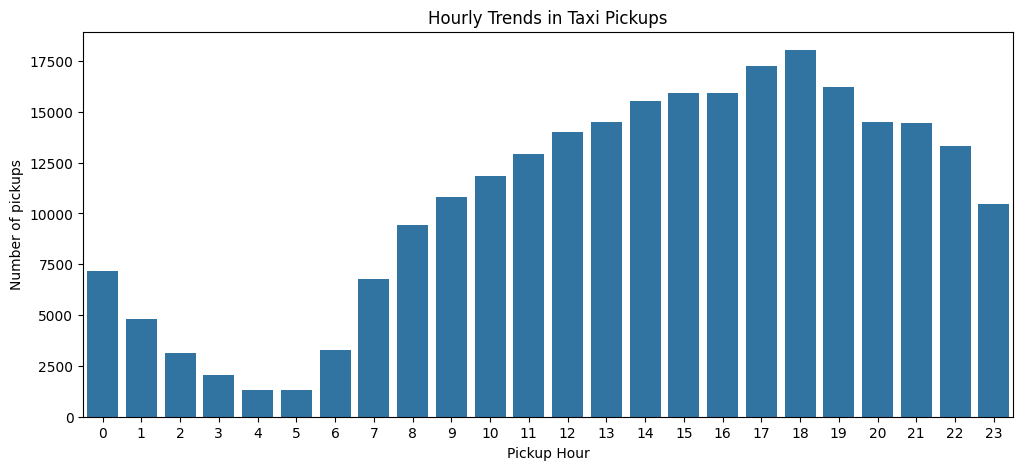

In [95]:
plt.figure(figsize=(12, 5))
sns.barplot(x=hourly_taxi_pickup.index, y=hourly_taxi_pickup.values)
plt.title('Hourly Trends in Taxi Pickups')
plt.xlabel('Pickup Hour')
plt.ylabel('Number of pickups')
plt.show()

In [96]:
# Find and show the daily trends in taxi pickups (days of the week)
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

pickup_daily_trends = df['pickup_day'].value_counts().reindex(day_order)
pickup_daily_trends

,count
pickup_day,
Monday,31768
Tuesday,36944
Wednesday,39203
Thursday,40003
Friday,37802
Saturday,37135
Sunday,32154


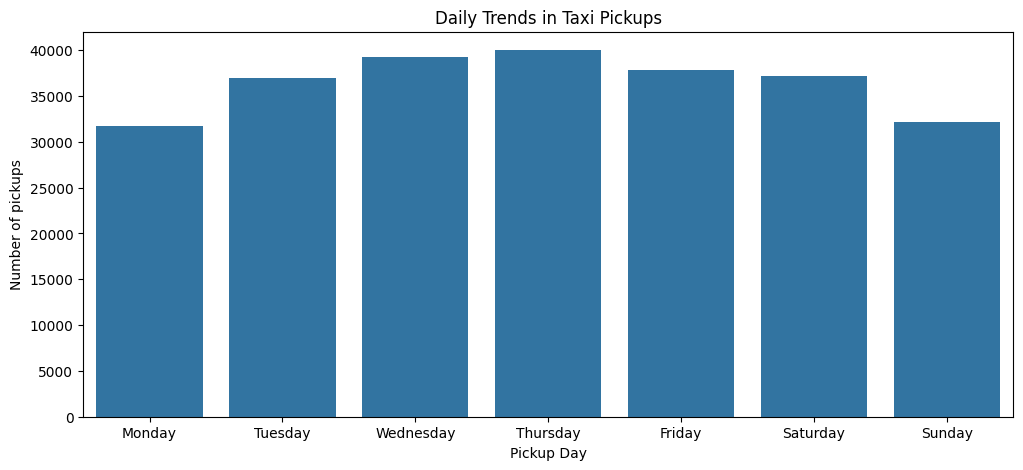

In [97]:
plt.figure(figsize=(12, 5))
sns.barplot(x=pickup_daily_trends.index, y=pickup_daily_trends.values)
plt.title('Daily Trends in Taxi Pickups')
plt.xlabel('Pickup Day')
plt.ylabel('Number of pickups')
plt.show()

In [98]:
# Show the monthly trends in pickups
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

pickup_monthly_trends = (df['pickup_month_name']
                        .value_counts()
                        .reindex(month_order))
pickup_monthly_trends

,count
pickup_month_name,
January,20683
February,19586
March,22846
April,22082
May,23548
June,22182
July,19451
August,18825
September,18641


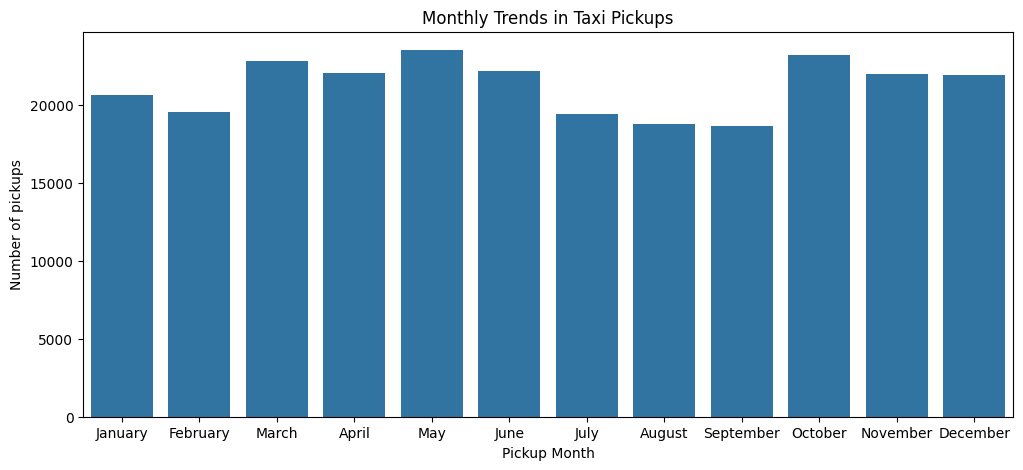

In [99]:
plt.figure(figsize=(12, 5))
sns.barplot(x=pickup_monthly_trends.index, y=pickup_monthly_trends.values)
plt.title('Monthly Trends in Taxi Pickups')
plt.xlabel('Pickup Month')
plt.ylabel('Number of pickups')
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [100]:
# Analyse the above parameters
financial_param = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

zero_cnt = (df[financial_param] == 0).sum()
neg_cnt = (df[financial_param] < 0).sum()
zero_perc = ((zero_cnt / df.shape[0]) * 100).round(2)
neg_perc = ((neg_cnt / df.shape[0]) * 100).round(2)

financial_analyze = pd.DataFrame({
    'zero_cnt': zero_cnt,
    'zero_perc': zero_perc,
    'neg_cnt': neg_cnt,
    'neg_perc': neg_perc
})

financial_analyze

,zero_cnt,zero_perc,neg_cnt,neg_perc
fare_amount,83,0.03,0,0.0
tip_amount,55785,21.88,0,0.0
total_amount,39,0.02,0,0.0
trip_distance,2933,1.15,0,0.0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

Answer: Yes. For financial analysis, I created separate dataframe "df_financial" by keeping only records with positive values for `fare_amount`, `tip_amount`, `total_amount`, `trip_distance`.

This helps avoid misleading and keep original dataframe unchanged for further analysis.

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [101]:
# Create a df with non zero entries for the selected parameters.

df_financial = df[((df['fare_amount'] > 0) &
                (df['tip_amount'] > 0) &
                (df['total_amount'] > 0) &
                (df['trip_distance'] > 0))].copy()

In [102]:
df_financial.reset_index(drop=True, inplace=True)

In [103]:
df_financial.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration,pickup_hour,pickup_month,pickup_day,pickup_month_name
0,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2,18.46,2,132,163,1,70.0,...,6.94,1.0,98.40,2.5,1.75,44.583333,0,9,Friday,September
1,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1,0.71,1,144,232,1,7.9,...,0.00,1.0,14.90,2.5,0.00,6.300000,0,9,Friday,September
2,2,2023-09-01 00:41:08,2023-09-01 00:54:33,5,4.39,1,79,263,1,19.1,...,0.00,1.0,28.92,2.5,0.00,13.416667,0,9,Friday,September
3,2,2023-09-01 00:07:47,2023-09-01 00:18:46,1,1.76,1,48,143,1,12.1,...,0.00,1.0,20.52,2.5,0.00,10.983333,0,9,Friday,September
4,2,2023-09-01 00:46:19,2023-09-01 01:00:11,1,6.32,1,233,33,1,26.1,...,0.00,1.0,37.32,2.5,0.00,13.866667,0,9,Friday,September


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

In [104]:
# Group data by month and analyse monthly revenue

monthly_revenue = df_financial.groupby('pickup_month_name')['total_amount'].sum()
monthly_revenue = monthly_revenue.reindex(month_order).reset_index()
monthly_revenue

,pickup_month_name,total_amount
0,January,453395.35
1,February,433033.39
2,March,518176.10
3,April,498149.51
4,May,551755.06
5,June,518644.78
6,July,430838.54
7,August,422519.10
8,September,446643.59
9,October,560883.23


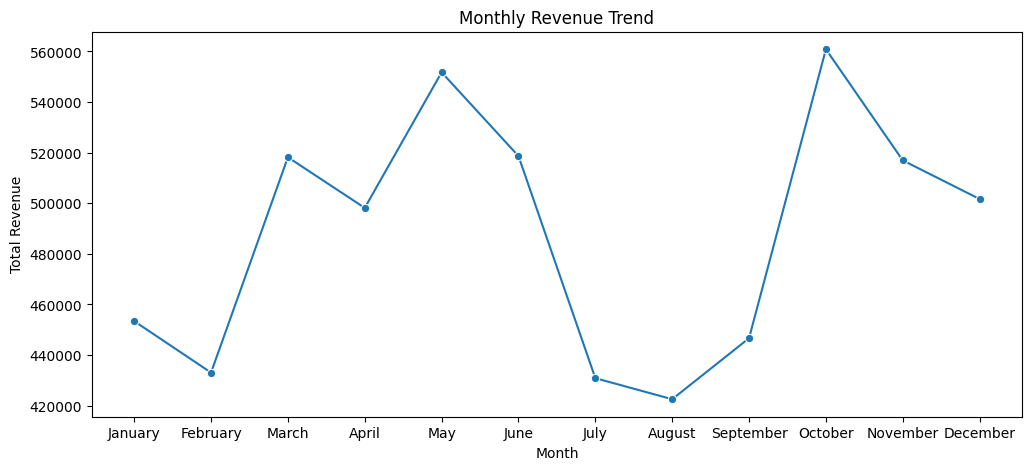

In [105]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_revenue,
    x='pickup_month_name',
    y='total_amount',
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [106]:
# Calculate proportion of each quarter

df_financial['pickup_quarter'] = df_financial['tpep_pickup_datetime'].dt.quarter
quarter_revenue = (df_financial.groupby('pickup_quarter')['total_amount']
                   .sum().reset_index())

quarter_revenue['revenue_percentage'] = (
    quarter_revenue['total_amount'] /
    quarter_revenue['total_amount'].sum() * 100
).round(2)

quarter_revenue

,pickup_quarter,total_amount,revenue_percentage
0,1,1404604.84,24.00
1,2,1568549.35,26.80
2,3,1300001.23,22.21
3,4,1579466.54,26.99


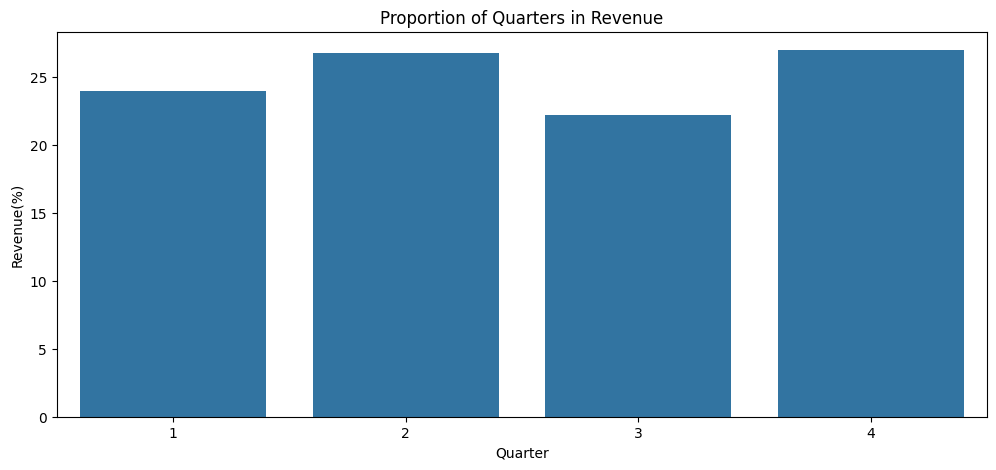

In [107]:
plt.figure(figsize=(12, 5))

sns.barplot(data=quarter_revenue, x='pickup_quarter', y='revenue_percentage')
plt.title('Proportion of Quarters in Revenue')
plt.xlabel('Quarter')
plt.ylabel('Revenue(%)')
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

In [108]:
# Show how trip fare is affected by distance

dist_fare_df = df[(df['trip_distance'] > 0) &
                  (df['fare_amount'] > 0)].copy()

distance_fare_corr = dist_fare_df['fare_amount'].corr(dist_fare_df['trip_distance'])

distance_fare_corr

0.9438872334868688

In [109]:
df_financial.shape

(198039, 24)

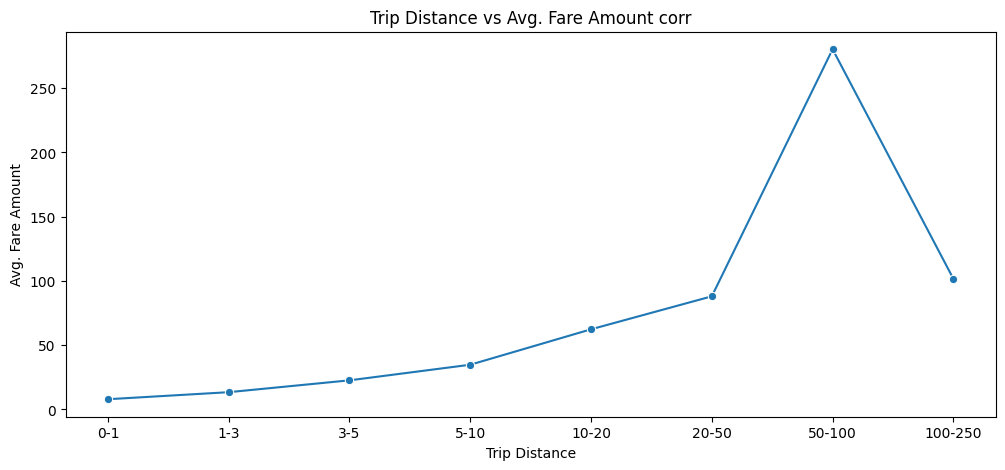

In [110]:
dist_fare_df['trip_dist_range'] = pd.cut(
    dist_fare_df['trip_distance'],
    bins=[0, 1, 3, 5, 10, 20, 50, 100, 250],
    labels=['0-1', '1-3', '3-5', '5-10', '10-20', '20-50', '50-100', '100-250']
)

dist_trip_fare = (dist_fare_df.groupby('trip_dist_range')['fare_amount']
                  .mean().reset_index())

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=dist_trip_fare,
    x='trip_dist_range',
    y='fare_amount',
    marker='o'
)

plt.title('Trip Distance vs Avg. Fare Amount corr')
plt.xlabel('Trip Distance')
plt.ylabel('Avg. Fare Amount')
plt.show()

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [111]:
# Show relationship between fare and trip duration
fare_trip_df = df[
    (df['fare_amount'] > 0) &
    (df['trip_duration'] > 0)
][['fare_amount', 'trip_duration']].copy()

fare_trip_corr = fare_trip_df.corr()
fare_trip_corr

,fare_amount,trip_duration
fare_amount,1.00000,0.26376
trip_duration,0.26376,1.00000


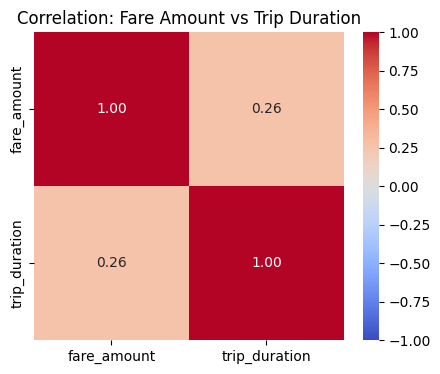

In [112]:
plt.figure(figsize=(5,4))

sns.heatmap(
    data=fare_trip_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)


plt.title('Correlation: Fare Amount vs Trip Duration')

plt.show()

In [113]:
# Show relationship between fare and number of passengers

fare_passanger_df = df[
    (df['fare_amount'] > 0) &
    (df['passenger_count'] > 0)][['fare_amount', 'passenger_count']].copy()

fare_passanger_corr = fare_passanger_df.corr()
fare_passanger_corr

,fare_amount,passenger_count
fare_amount,1.000000,0.046645
passenger_count,0.046645,1.000000


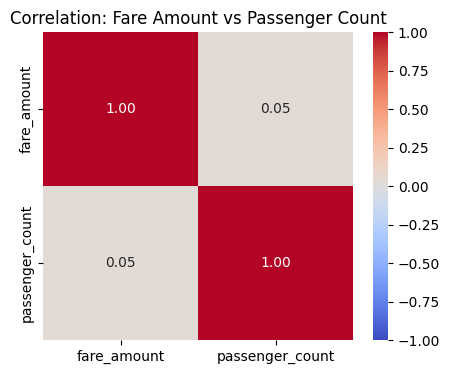

In [114]:
plt.figure(figsize=(5,4))

sns.heatmap(
    data=fare_passanger_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Correlation: Fare Amount vs Passenger Count')
plt.show()

In [115]:
# Show relationship between tip and trip distance

tip_trip_dist_df = df[
                  (df['tip_amount'] >= 0) &
                  (df['trip_distance'] > 0)
                ][['tip_amount', 'trip_distance']].copy()

tip_trip_dist_corr = tip_trip_dist_df.corr()
tip_trip_dist_corr

,tip_amount,trip_distance
tip_amount,1.00000,0.59721
trip_distance,0.59721,1.00000


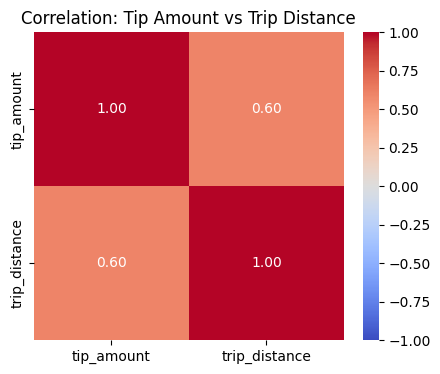

In [116]:
plt.figure(figsize=(5,4))

sns.heatmap(
    data=tip_trip_dist_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)
plt.title('Correlation: Tip Amount vs Trip Distance')
plt.show()

In [117]:
# Analysis Interpretation

fare_trip_value = fare_trip_corr.loc['fare_amount', 'trip_duration']
fare_passanger_value = fare_passanger_corr.loc['fare_amount', 'passenger_count']
tip_trip_dist_value = tip_trip_dist_corr.loc['tip_amount', 'trip_distance']

print(f"""
Fare amount and trip duration have a correlation of {fare_trip_value:.2f}.

Fare amount and passenger count have a correlation of {fare_passanger_value:.2f}.

Tip amount and trip distance have a correlation of {tip_trip_dist_value:.2f}.
""")


Fare amount and trip duration have a correlation of 0.26.

Fare amount and passenger count have a correlation of 0.05.

Tip amount and trip distance have a correlation of 0.60.



**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [118]:
# Analyse the distribution of different payment types (payment_type).


payment_type_mapping = {
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided trip'
}

payment_type_df = df.copy()

payment_type_df['payment_type_label'] = payment_type_df['payment_type'].map(
    payment_type_mapping)

payment_type_df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration,pickup_hour,pickup_month,pickup_day,pickup_month_name,payment_type_label
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2,0.56,1,142,142,2,5.1,...,1.0,10.10,2.5,0.00,2.483333,0,9,Friday,September,Cash
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2,18.46,2,132,163,1,70.0,...,1.0,98.40,2.5,1.75,44.583333,0,9,Friday,September,Credit card
3,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2,13.71,1,249,180,4,59.7,...,1.0,64.70,2.5,0.00,38.116667,0,9,Friday,September,Dispute
4,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1,0.71,1,144,232,1,7.9,...,1.0,14.90,2.5,0.00,6.300000,0,9,Friday,September,Credit card
5,2,2023-09-01 00:41:08,2023-09-01 00:54:33,5,4.39,1,79,263,1,19.1,...,1.0,28.92,2.5,0.00,13.416667,0,9,Friday,September,Credit card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265481,2,2023-11-30 23:30:19,2023-11-30 23:37:08,1,0.91,1,4,79,1,7.9,...,1.0,16.12,2.5,0.00,6.816667,23,11,Thursday,November,Credit card
265482,2,2023-11-30 23:32:06,2023-11-30 23:36:20,1,0.80,1,263,237,1,5.8,...,1.0,11.88,2.5,0.00,4.233333,23,11,Thursday,November,Credit card
265483,2,2023-11-30 23:15:22,2023-11-30 23:43:31,3,9.89,1,230,223,1,42.9,...,1.0,65.81,2.5,0.00,28.150000,23,11,Thursday,November,Credit card
265484,2,2023-11-30 23:30:10,2023-11-30 23:53:57,1,4.90,1,186,65,1,26.1,...,1.0,36.68,2.5,0.00,23.783333,23,11,Thursday,November,Credit card


In [119]:
payment_dist = (payment_type_df['payment_type_label'].value_counts(dropna=False)
.sort_index(ascending=False).reset_index())

payment_dist

,payment_type_label,count
0,No charge,1219
1,Dispute,1910
2,Credit card,207515
3,Cash,44365


In [120]:
payment_type_df['payment_type_label'].isna().sum()

0

In [121]:
payment_dist.columns = ['payment_type', 'trip_count']

payment_dist['trip_percentage'] = (payment_dist['trip_count'] /
                                   len(payment_type_df) * 100)

payment_dist

,payment_type,trip_count,trip_percentage
0,No charge,1219,0.478022
1,Dispute,1910,0.748993
2,Credit card,207515,81.375559
3,Cash,44365,17.397425


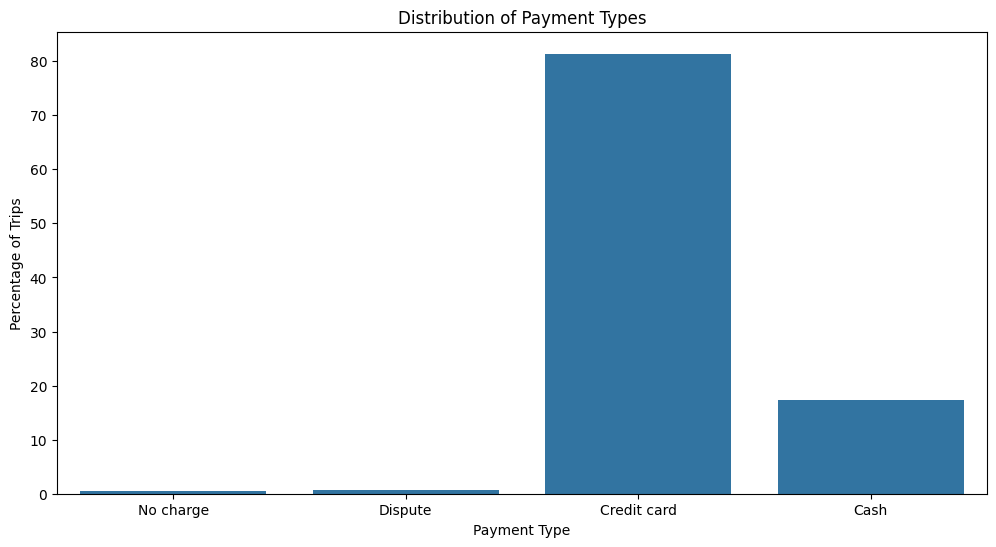

In [122]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data = payment_dist,
    x = 'payment_type',
    y= 'trip_percentage'
)

plt.title('Distribution of Payment Types')
plt.xlabel('Payment Type')
plt.ylabel('Percentage of Trips')
plt.show()

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [123]:
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [124]:
os.chdir('/content/drive/MyDrive/IIITB_Course/Assignment_1/Datasets_and_Dictionary_nyc/taxi_zones/')

# Create a list of all the twelve files to read
file_list = os.listdir()
file_list

['taxi_zones.shx',
 'taxi_zones.sbx',
 'taxi_zones.shp.xml',
 'taxi_zones.shp',
 'taxi_zones.dbf',
 'taxi_zones.sbn',
 'taxi_zones.prj']

In [125]:
import geopandas as gpd


# Read the shapefile using geopandas
zones = gpd.read_file('taxi_zones.shp')
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

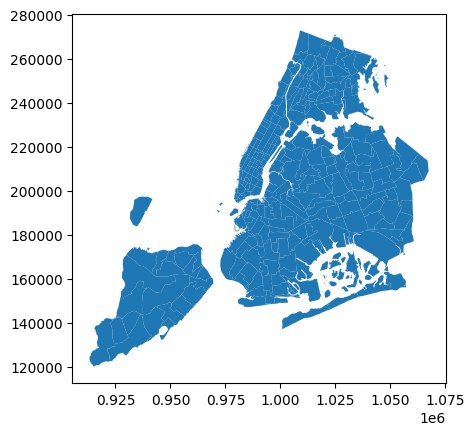

In [126]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [127]:
# Merge zones and trip records using locationID and PULocationID

zones_df = zones[['LocationID', 'zone', 'borough']].copy()

zone_df = zones_df.rename(columns={
    'LocationID': 'PULocationID',
    'zone': 'pickup_zone',
    'borough': 'pickup_borough'
})

zone_trips_df = df.merge(zone_df, on='PULocationID', how='left')
zone_trips_df[['PULocationID', 'pickup_zone', 'pickup_borough']].head()

,PULocationID,pickup_zone,pickup_borough
0,142,Lincoln Square East,Manhattan
1,132,JFK Airport,Queens
2,249,West Village,Manhattan
3,144,Little Italy/NoLiTa,Manhattan
4,79,East Village,Manhattan


In [128]:
zone_trips_df['pickup_zone'].isna().sum()

2571

**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [129]:
# Group data by location and calculate the number of trips

zone_trip_group_data = (zone_trips_df.groupby('PULocationID')
                        .size()
                        .reset_index(name='trip_count')
                        .sort_values('trip_count', ascending=False))
zone_trip_group_data.head()

,PULocationID,trip_count
100,132,13584
189,237,12113
126,161,12023
188,236,10794
127,162,9282


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [130]:
# Merge trip counts back to the zones GeoDataFrame

zone_trip_merge = zones.merge(
      zone_trip_group_data.rename(columns = {'PULocationID': 'LocationID'}),
      on = 'LocationID',
      how = 'left'
    )

In [131]:
zone_trip_merge['trip_count'] = zone_trip_merge['trip_count'].fillna(0)

In [132]:
zone_trip_merge['trip_count'].dtypes

dtype('float64')

In [133]:
zone_trip_merge['trip_count'].astype(int).head(3)

,trip_count
0,36
1,0
2,1


In [134]:
zone_trip_merge.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",36.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",0.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",1.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",241.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",0.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

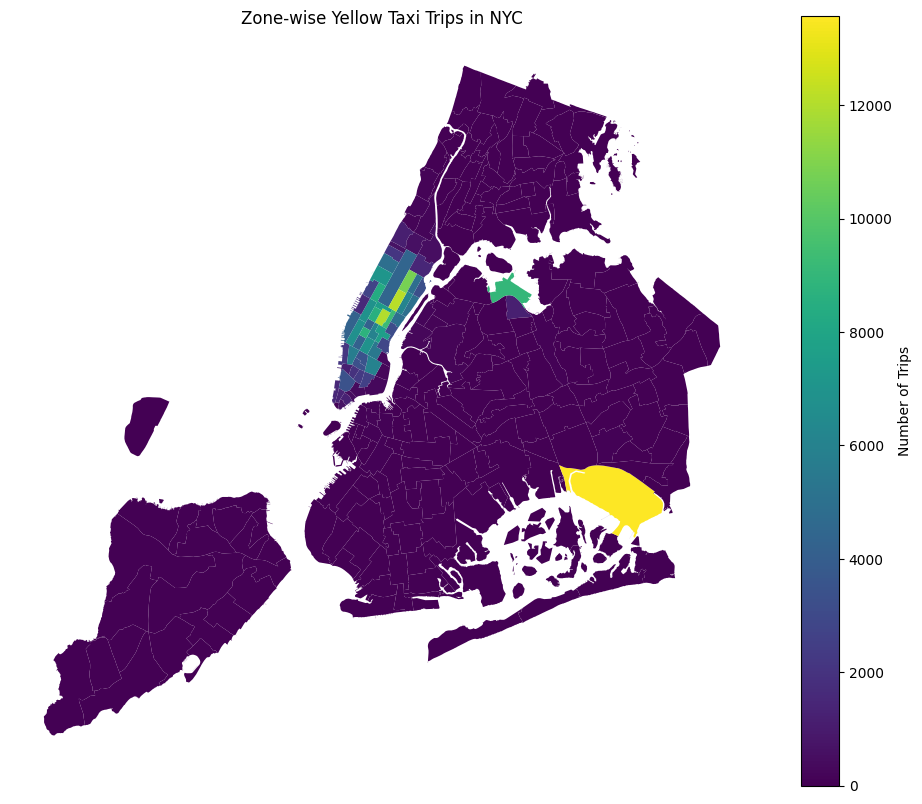

In [135]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

# Plot the map and display it
zone_trip_merge.plot(
    column = 'trip_count',
    ax = ax,
    legend = True,
    legend_kwds = {
        'label': "Number of Trips",
        'orientation': 'vertical'
    }
)

ax.set_title('Zone-wise Yellow Taxi Trips in NYC')
ax.set_axis_off()

plt.show()

In [136]:
# can you try displaying the zones DF sorted by the number of trips?

(zone_trip_merge[['LocationID', 'zone', 'borough', 'trip_count']]
 .sort_values(by='trip_count', ascending=False)
 .head())

,LocationID,zone,borough,trip_count
131,132,JFK Airport,Queens,13584.0
236,237,Upper East Side South,Manhattan,12113.0
160,161,Midtown Center,Manhattan,12023.0
235,236,Upper East Side North,Manhattan,10794.0
161,162,Midtown East,Manhattan,9282.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

In [137]:
# General Analysis

print("""
From the general EDA, taxi pickup show clear variation by hour, day and month.
Revenue also changes across months, showing that demand and earnings are not evenly
distributed across the year.

Fare amount has a strong relation with trip distance, while passenger count has
weak relationship with fare amount.

The geographical analysis also shows that trip activity is concentrated in selected
high demand zones instead of being evenly spread across all NYC taxi zones.
""")


From the general EDA, taxi pickup show clear variation by hour, day and month.
Revenue also changes across months, showing that demand and earnings are not evenly 
distributed across the year.

Fare amount has a strong relation with trip distance, while passenger count has
weak relationship with fare amount.

The geographical analysis also shows that trip activity is concentrated in selected
high demand zones instead of being evenly spread across all NYC taxi zones.



You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [138]:
# Find routes which have the slowest speeds at different times of the day

drop_off_zone_df = zones_df.rename(columns = {
    'LocationID': 'DOLocationID',
    'zone': 'dropoff_zone',
    'borough': 'dropoff_borough'
})

trip_zones = zone_trips_df.merge(drop_off_zone_df,
                                 on = 'DOLocationID', how = 'left')

In [139]:
trip_zones[['PULocationID', 'pickup_zone', 'DOLocationID', 'dropoff_zone']].head()

,PULocationID,pickup_zone,DOLocationID,dropoff_zone
0,142,Lincoln Square East,142,Lincoln Square East
1,132,JFK Airport,163,Midtown North
2,249,West Village,180,Ozone Park
3,144,Little Italy/NoLiTa,232,Two Bridges/Seward Park
4,79,East Village,263,Yorkville West


In [140]:
trip_zones[['trip_distance','trip_duration']].value_counts()

trip_distance  trip_duration
0.00           0.100000         125
               0.066667         115
               0.133333         106
               0.166667         104
               0.116667         101
                               ... 
2.04           10.166667          1
               10.116667          1
               10.000000          1
               9.983333           1
187.35         167.900000         1
Name: count, Length: 175416, dtype: int64

In [141]:
speed_df = trip_zones[
    (trip_zones['trip_distance'] > 0) &
    (trip_zones['trip_duration'] > 0)
].copy()

speed_df.head(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,airport_fee,trip_duration,pickup_hour,pickup_month,pickup_day,pickup_month_name,pickup_zone,pickup_borough,dropoff_zone,dropoff_borough
0,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2,0.56,1,142,142,2,5.1,...,0.00,2.483333,0,9,Friday,September,Lincoln Square East,Manhattan,Lincoln Square East,Manhattan
1,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2,18.46,2,132,163,1,70.0,...,1.75,44.583333,0,9,Friday,September,JFK Airport,Queens,Midtown North,Manhattan


In [142]:
speed_df['speed_mph'] = speed_df['trip_distance'] / (speed_df['trip_duration'] / 60)

In [143]:
speed_df['speed_mph'].sort_values(ascending=False).head(5)

,speed_mph
103608,17550.000000
93395,13680.000000
47059,12600.000000
1860,11040.000000
223627,9012.857143


In [144]:
speed_df['speed_mph'].quantile([0.25, 0.50, 0.75, 0.90, 0.99, 1])

,speed_mph
0.25,7.184101
0.50,9.654967
0.75,13.351499
0.90,19.841182
0.99,35.677912
1.00,17550.000000


In [145]:
speed_max_limit = speed_df['speed_mph'].quantile(0.99)
speed_df = speed_df[
    (speed_df['speed_mph'] > 0) &
    (speed_df['speed_mph'] <= speed_max_limit)].copy()

In [146]:
speed_df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee', 'trip_duration', 'pickup_hour',
       'pickup_month', 'pickup_day', 'pickup_month_name', 'pickup_zone',
       'pickup_borough', 'dropoff_zone', 'dropoff_borough', 'speed_mph'],
      dtype='object')

In [147]:
route_hrs_analysis_cols = ['pickup_hour', 'PULocationID', 'pickup_zone',
                           'DOLocationID', 'dropoff_zone']

# Count Trips by route-hrs combination and calculate avg. trip dist
trip_cnt_df = (
    speed_df.groupby(route_hrs_analysis_cols).size()
    .reset_index(name='trip_count'))

# Avg. trip distance for each route-hrs combination
avg_dist_df = (speed_df.groupby(route_hrs_analysis_cols)['trip_distance']
    .mean().reset_index(name='avg_trip_distance'))

# Avg. trip duration for each route-hrs combination
avg_duration_df = (speed_df.groupby(route_hrs_analysis_cols)['trip_duration']
                   .mean().reset_index(name='avg_trip_duration_min'))

# Avg. trip speed for each route-hrs combination
avg_speed_df = (speed_df
                .groupby(route_hrs_analysis_cols)['speed_mph']
                .mean().reset_index(name='avg_speed_mph'))

In [148]:
# Merge all into one
route_hrs_speed = trip_cnt_df.merge(avg_dist_df,
                                    on=route_hrs_analysis_cols,
                                    how='left')

route_hrs_speed = route_hrs_speed.merge(avg_duration_df,
                                      on=route_hrs_analysis_cols,
                                      how='left')

route_hrs_speed = route_hrs_speed.merge(avg_speed_df,
                                      on=route_hrs_analysis_cols,
                                      how='left')

route_hrs_speed.head()

,pickup_hour,PULocationID,pickup_zone,DOLocationID,dropoff_zone,trip_count,avg_trip_distance,avg_trip_duration_min,avg_speed_mph
0,0,4,Alphabet City,13,Battery Park City,1,4.16,11.500000,21.704348
1,0,4,Alphabet City,17,Bedford,1,4.25,21.150000,12.056738
2,0,4,Alphabet City,33,Brooklyn Heights,1,3.90,14.883333,15.722284
3,0,4,Alphabet City,43,Central Park,1,6.31,22.500000,16.826667
4,0,4,Alphabet City,50,Clinton West,1,4.33,25.716667,10.102398


In [149]:
route_hrs_speed['trip_count'].quantile([0.25, 0.50, 0.75, 0.90, 0.99])

,trip_count
0.25,1.0
0.50,2.0
0.75,5.0
0.90,10.0
0.99,30.0


In [150]:
min_route_trip_count = route_hrs_speed['trip_count'].quantile(0.90)

# Keep route-hrs combination with enough trips to make validate avg. speed
valid_routes = route_hrs_speed[
              route_hrs_speed['trip_count'] >= min_route_trip_count].copy()

In [151]:
print(route_hrs_speed.shape[0], valid_routes.shape[0])

57117 6405


In [152]:
valid_routes['route'] = (valid_routes['pickup_zone'] +
                         ' -> ' + valid_routes['dropoff_zone'])

In [153]:
# Identify slowest valid route-hrs combinations
slow_routes = valid_routes.sort_values(by='avg_speed_mph').head(10)

slow_routes[[
    'pickup_hour', 'route', 'trip_count', 'avg_trip_distance',
    'avg_trip_duration_min', 'avg_speed_mph'
]]

,pickup_hour,route,trip_count,avg_trip_distance,avg_trip_duration_min,avg_speed_mph
44149,19,Times Sq/Theatre District -> Times Sq/Theatre ...,19,0.468421,9.734211,3.089979
30461,15,Garment District -> Clinton East,11,0.678182,12.287879,3.380040
20569,11,Penn Station/Madison Sq West -> Garment District,10,0.678000,15.660000,3.400969
26003,13,Murray Hill -> Times Sq/Theatre District,20,0.979000,86.615833,3.466732
34443,16,Midtown Center -> Times Sq/Theatre District,20,0.639000,11.561667,3.508678
25712,13,Midtown Center -> Times Sq/Theatre District,19,0.584211,11.277193,3.658627
24805,13,Garment District -> Times Sq/Theatre District,12,0.815833,13.944444,3.726184
23330,12,Penn Station/Madison Sq West -> Times Sq/Theat...,37,0.968919,18.711261,3.747502
20601,11,Penn Station/Madison Sq West -> Times Sq/Theat...,40,1.060500,19.248750,3.774731
28656,14,Midtown East -> Times Sq/Theatre District,12,1.190000,19.347222,3.788424


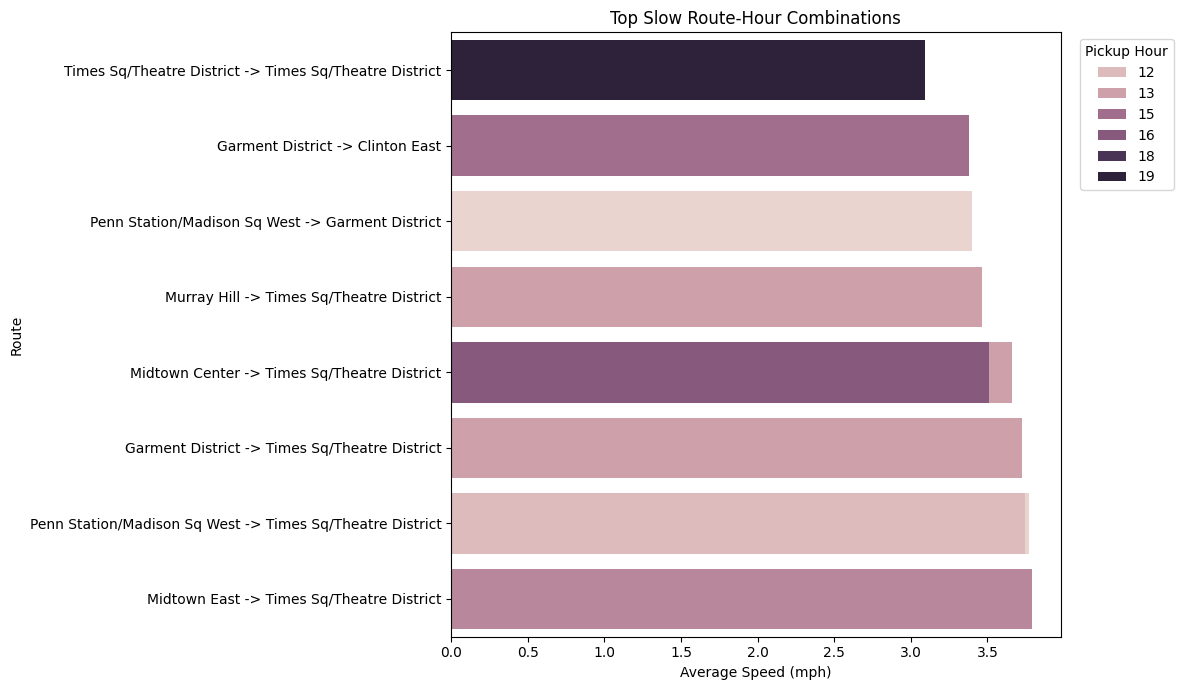

In [154]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=slow_routes.head(10),
    x='avg_speed_mph',
    y='route',
    hue='pickup_hour',
    dodge=False
)
plt.title('Top Slow Route-Hour Combinations')
plt.xlabel('Average Speed (mph)')
plt.ylabel('Route')
plt.legend(title='Pickup Hour', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [155]:
print("""
Approach:
To observe trip speed for each route during each pick hour we calculate speed
first and then average i across each route-hour.
""")


Approach:
To observe trip speed for each route during each pick hour we calculate speed
first and then average i across each route-hour.



How does identifying high-traffic, high-demand routes help us?

ANSWER:

Identifying high-traffic and high-demand routes helps us understand where taxi demand is strong, which routes are busiest, and which pickup locations need more cab availability.

If the company places more taxis near these high-demand pickup locations, passengers can get taxis faster and drivers can complete more trips.

It also helps us identify busy routes that are slow. This can help the company plan better, improve route efficiency, and enhance overall service quality.

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [156]:
df[['tpep_pickup_datetime', 'pickup_hour']].head()

,tpep_pickup_datetime,pickup_hour
1,2023-09-01 00:24:50,0
2,2023-09-01 00:19:27,0
3,2023-09-01 00:42:13,0
4,2023-09-01 00:11:38,0
5,2023-09-01 00:41:08,0


In [157]:
# Unique values
sorted(df['pickup_hour'].dropna().unique())

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23]

In [158]:
# Count no. of trips at each pickup hour
hourly_trips = (df.groupby('pickup_hour')
                .size().reset_index(name='trip_count')
                .sort_values('pickup_hour')
                .reset_index(drop=True))

hourly_trips

,pickup_hour,trip_count
0,0,7155
1,1,4786
2,2,3144
3,3,2043
4,4,1317
5,5,1315
6,6,3278
7,7,6753
8,8,9444
9,9,10821


In [159]:
print(f"Number of unique pickup hrs: {hourly_trips['pickup_hour'].nunique()}")

Number of unique pickup hrs: 24


In [160]:
# Check busiest hr based on highesst trip count

busiest_hr_row = hourly_trips.loc[hourly_trips['trip_count'].idxmax()]

busiest_hr_row

,18
pickup_hour,18
trip_count,18039


In [161]:
busiest_hr = busiest_hr_row['pickup_hour']
busiest_hr_trips = busiest_hr_row['trip_count']


print(f"Busiest Hrs: {busiest_hr} and Trips: {busiest_hr_trips}")

Busiest Hrs: 18 and Trips: 18039


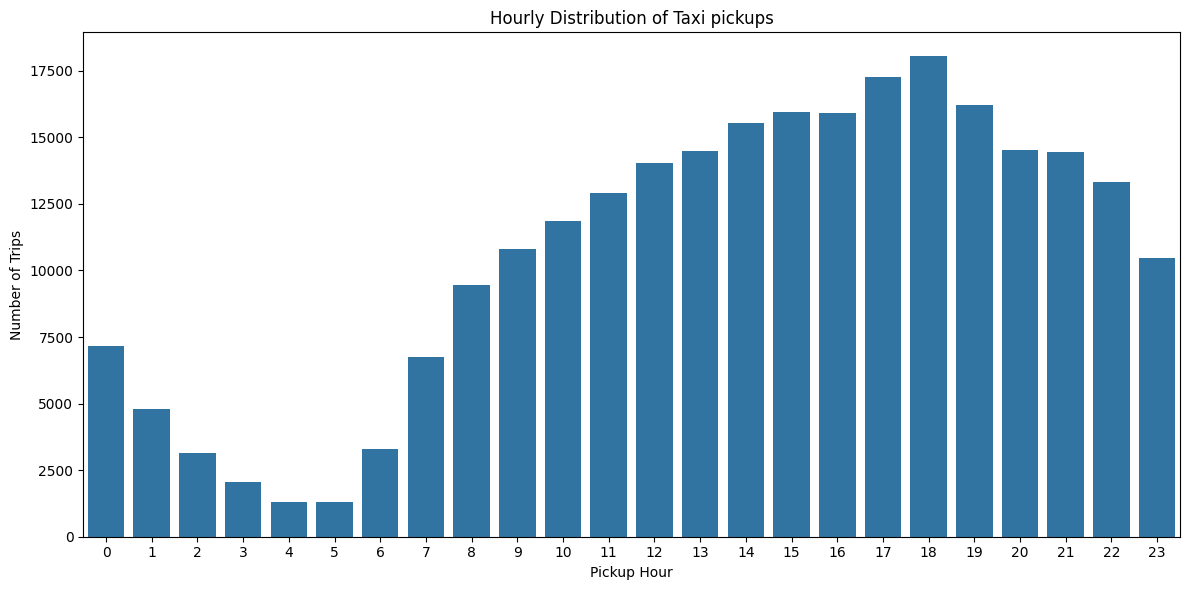

In [162]:
# Visualise the number of trips per hour and find the busiest hour

plt.figure(figsize=(12, 6))

sns.barplot(
    data = hourly_trips,
    x = 'pickup_hour',
    y = 'trip_count'
)

plt.title('Hourly Distribution of Taxi pickups')
plt.xlabel('Pickup Hour')
plt.ylabel('Number of Trips')

plt.tight_layout()
plt.show()

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [163]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.007

scaling_factor = 1 / sample_fraction


In [164]:
# Create separate DataFrame to safe original dataframe
hourly_trips_scaled = hourly_trips.copy()

# Scale up the number of trips
hourly_trips_scaled['estimated_actual_trips'] = (
    hourly_trips_scaled['trip_count'] * scaling_factor
    ).round(0).astype(int)

hourly_trips_scaled

,pickup_hour,trip_count,estimated_actual_trips
0,0,7155,1022143
1,1,4786,683714
2,2,3144,449143
3,3,2043,291857
4,4,1317,188143
5,5,1315,187857
6,6,3278,468286
7,7,6753,964714
8,8,9444,1349143
9,9,10821,1545857


In [165]:
sample_total_trips = hourly_trips_scaled['trip_count'].sum()
estimated_total_trips = hourly_trips_scaled['estimated_actual_trips'].sum()

print(f"Sample Total Trips: {sample_total_trips}")
print(f"Estimated Total Trips: {estimated_total_trips}")
print(f"Scaling factor: {scaling_factor:.2f}")

Sample Total Trips: 255009
Estimated Total Trips: 36429858
Scaling factor: 142.86


In [166]:
# Identify top 5 busiest pickup hours

top_five_busiest_hrs = (hourly_trips_scaled
                        .sort_values('trip_count', ascending=False)
                        .head(5).reset_index(drop=True))

top_five_busiest_hrs

,pickup_hour,trip_count,estimated_actual_trips
0,18,18039,2577000
1,17,17256,2465143
2,19,16204,2314857
3,15,15938,2276857
4,16,15923,2274714


In [167]:
# Display sampled and estimated actual trips for the five busiest hours
top_five_busiest_hrs[['pickup_hour', 'trip_count', 'estimated_actual_trips']]

,pickup_hour,trip_count,estimated_actual_trips
0,18,18039,2577000
1,17,17256,2465143
2,19,16204,2314857
3,15,15938,2276857
4,16,15923,2274714


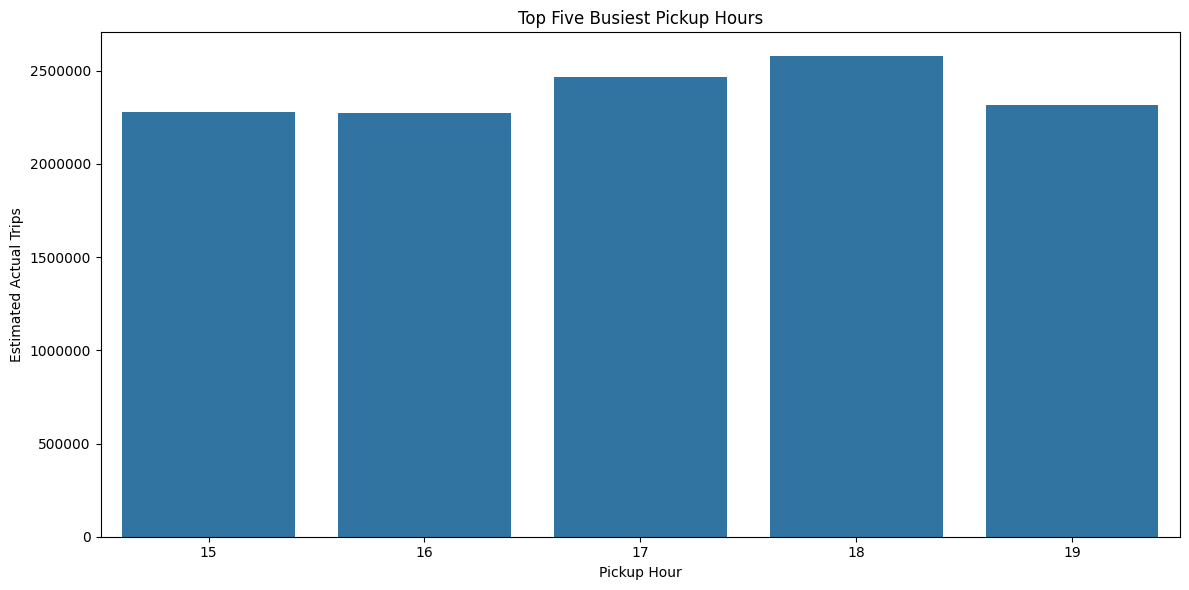

In [168]:
plt.figure(figsize=(12,6))

sns.barplot(
    data = top_five_busiest_hrs,
    x='pickup_hour',
    y='estimated_actual_trips'
)

plt.title('Top Five Busiest Pickup Hours')
plt.xlabel('Pickup Hour')
plt.ylabel('Estimated Actual Trips')

plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [169]:
# Interpretation of Task
top_hr = int(top_five_busiest_hrs.loc[0, 'pickup_hour'])
top_hr_trips = int(top_five_busiest_hrs.loc[0, 'trip_count'])
top_hr_estimated_trips = int(top_five_busiest_hrs.loc[0, 'estimated_actual_trips'])

print(f"""
      The Busiest Hr: {top_hr} and trip: {top_hr_trips}.
      Afer scaling sampling: {scaling_factor},
      The actual number of trips for this Hr is approx {top_hr_estimated_trips}.

      This Data represents the strong demand and should be priortised for taxi
      availability, driver scheduling.
      """)


      The Busiest Hr: 18 and trip: 18039.
      Afer scaling sampling: 142.85714285714286,
      The actual number of trips for this Hr is approx 2577000.

      This Data represents the strong demand and should be priortised for taxi
      availability, driver scheduling.
      


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [170]:
# Compare traffic trends for the week days and weekends

# To perform avg. trips per day we need to total trips the
# day_type[Weekday, weekend]

# Analyse traffic hourly

weekend_weekday_df = (df[[
                          'tpep_pickup_datetime',
                          'pickup_day',
                          'pickup_hour']].copy())

weekend_weekday_df.head()

,tpep_pickup_datetime,pickup_day,pickup_hour
1,2023-09-01 00:24:50,Friday,0
2,2023-09-01 00:19:27,Friday,0
3,2023-09-01 00:42:13,Friday,0
4,2023-09-01 00:11:38,Friday,0
5,2023-09-01 00:41:08,Friday,0


In [171]:
weekend_weekday_df['pickup_date'] = (weekend_weekday_df['tpep_pickup_datetime']
                                     .dt.date)

weekend_weekday_df['day_type'] = np.where(
    weekend_weekday_df['pickup_day'].isin(['Saturday', 'Sunday']),
    'Weekend', 'Weekday'
)

weekend_weekday_df.head()

,tpep_pickup_datetime,pickup_day,pickup_hour,pickup_date,day_type
1,2023-09-01 00:24:50,Friday,0,2023-09-01,Weekday
2,2023-09-01 00:19:27,Friday,0,2023-09-01,Weekday
3,2023-09-01 00:42:13,Friday,0,2023-09-01,Weekday
4,2023-09-01 00:11:38,Friday,0,2023-09-01,Weekday
5,2023-09-01 00:41:08,Friday,0,2023-09-01,Weekday


In [172]:
# Validate Result between weekday and weakend

(weekend_weekday_df[['pickup_day', 'day_type']]
 .drop_duplicates()
 .sort_values('pickup_day'))

,pickup_day,day_type
1,Friday,Weekday
1719,Monday,Weekday
601,Saturday,Weekend
1171,Sunday,Weekend
3743,Thursday,Weekday
2219,Tuesday,Weekday
2927,Wednesday,Weekday


In [173]:
# Count unique pickup dates for weekdays and weekeds

date_count_by_day_type = (
    weekend_weekday_df.groupby('day_type')['pickup_date']
    .nunique().reset_index(name='unique_pickup_dates')
)

date_count_by_day_type

,day_type,unique_pickup_dates
0,Weekday,259
1,Weekend,104


In [174]:
# Calculate total trips by day type and pickup hour

hourly_day_type_trips = (
    weekend_weekday_df.groupby(['day_type', 'pickup_hour'])
    .size().reset_index(name='trip_count')
    .sort_values(['day_type', 'pickup_hour'])
)

hourly_day_type_trips.head()

,day_type,pickup_hour,trip_count
0,Weekday,0,3571
1,Weekday,1,1811
2,Weekday,2,976
3,Weekday,3,602
4,Weekday,4,561


In [175]:
# Merge avg. hourly day_type with date_count_by_day_type

hourly_day_type_trips = hourly_day_type_trips.merge(
    date_count_by_day_type,
    on='day_type',
    how='left',
    validate='many_to_one'
)

hourly_day_type_trips['avg_trips_per_day'] = (
    hourly_day_type_trips['trip_count'] /
    hourly_day_type_trips['unique_pickup_dates']
)


In [176]:
hourly_day_type_trips.head()

,day_type,pickup_hour,trip_count,unique_pickup_dates,avg_trips_per_day
0,Weekday,0,3571,259,13.787645
1,Weekday,1,1811,259,6.992278
2,Weekday,2,976,259,3.768340
3,Weekday,3,602,259,2.324324
4,Weekday,4,561,259,2.166023


In [177]:
# Find busiest pickup hour by day_type

busiest_hr_by_day_type = (
    hourly_day_type_trips
    .sort_values('avg_trips_per_day', ascending=False)
    .groupby('day_type').head(1).reset_index(drop=True)
)

busiest_hr_by_day_type

,day_type,pickup_hour,trip_count,unique_pickup_dates,avg_trips_per_day
0,Weekday,18,13714,259,52.949807
1,Weekend,17,4351,104,41.836538


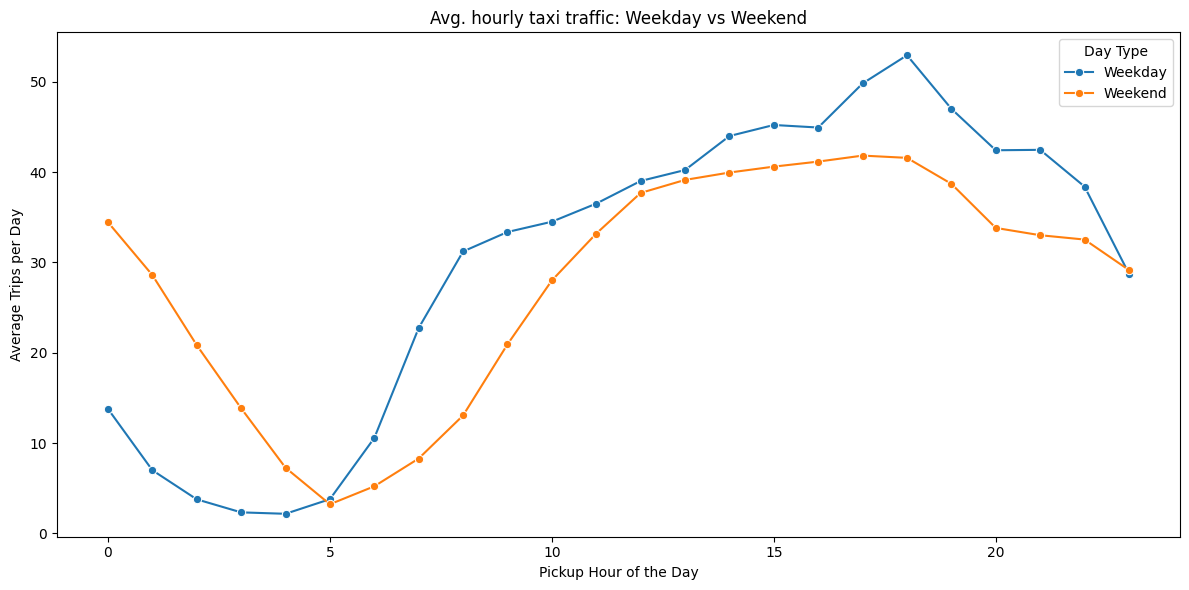

In [178]:
# Visualize Trend/Pattern across time(Weekday, Weekend)
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_day_type_trips,
    x='pickup_hour',
    y='avg_trips_per_day',
    hue='day_type',
    marker='o'
)

plt.title('Avg. hourly taxi traffic: Weekday vs Weekend')
plt.xlabel('Pickup Hour of the Day')
plt.ylabel('Average Trips per Day')
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

In [179]:
# Estimate actual avg. trips per day using sample_data scaling factor

hourly_day_type_trips['est_actual_trips_per_day'] = (
    hourly_day_type_trips['avg_trips_per_day'] * scaling_factor
).round(0).astype(int)

hourly_day_type_trips.head()

,day_type,pickup_hour,trip_count,unique_pickup_dates,avg_trips_per_day,est_actual_trips_per_day
0,Weekday,0,3571,259,13.787645,1970
1,Weekday,1,1811,259,6.992278,999
2,Weekday,2,976,259,3.768340,538
3,Weekday,3,602,259,2.324324,332
4,Weekday,4,561,259,2.166023,309


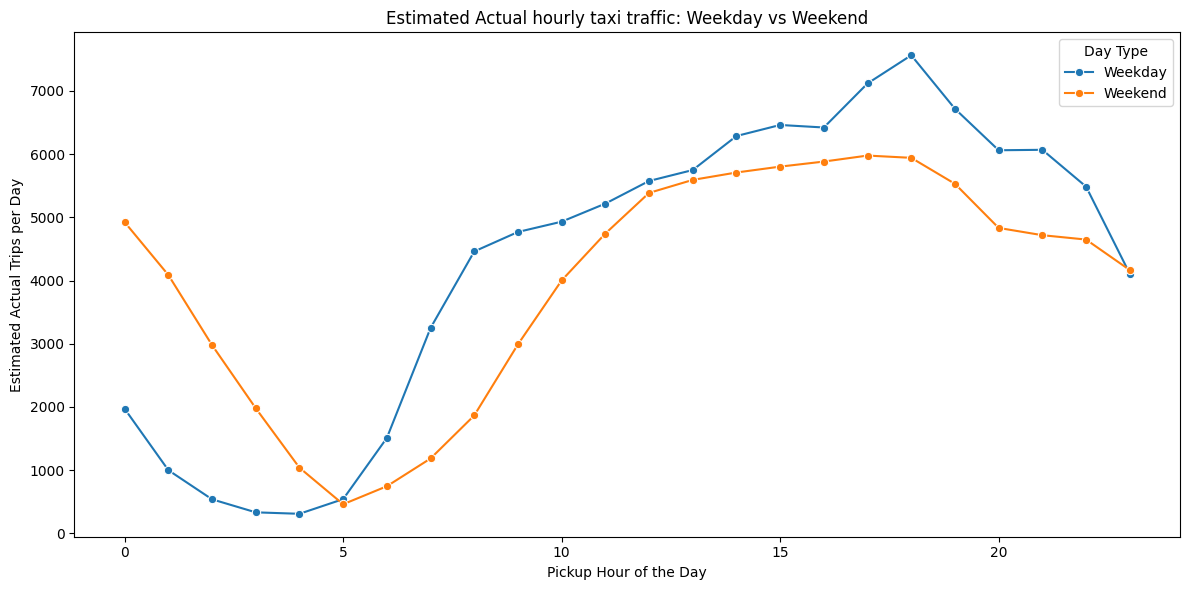

In [180]:
# Visualize Estimated actual avg. hourly traffic for weekedn and weekdays

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_day_type_trips,
    x='pickup_hour',
    y='est_actual_trips_per_day',
    hue='day_type',
    marker='o')

plt.title('Estimated Actual hourly taxi traffic: Weekday vs Weekend')
plt.xlabel('Pickup Hour of the Day')
plt.ylabel('Estimated Actual Trips per Day')
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

In [181]:
busiest_hr_by_analysis = busiest_hr_by_day_type.set_index('day_type')

weekday_peak = busiest_hr_by_analysis.loc['Weekday', 'pickup_hour']
weekend_peak = busiest_hr_by_analysis.loc['Weekend', 'pickup_hour']

weekday_avg_peak = busiest_hr_by_analysis.loc['Weekday', 'avg_trips_per_day']
weekend_avg_peak = busiest_hr_by_analysis.loc['Weekend', 'avg_trips_per_day']

print(f"Weekday peak hour: {int(weekday_peak)}:00 and with avg. trips per day: {weekday_avg_peak:.2f}")
print(f"Weekend peak hour: {int(weekend_peak)}:00 and with avg. trips per day: {weekend_avg_peak:.2f}")

Weekday peak hour: 18:00 and with avg. trips per day: 52.95
Weekend peak hour: 17:00 and with avg. trips per day: 41.84


**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [182]:
# Find top 10 pickup and dropoff zones

In [183]:
zone_hourly_df = trip_zones[[
    'PULocationID', 'pickup_zone', 'pickup_borough',
    'DOLocationID', 'dropoff_zone', 'dropoff_borough',
    'pickup_hour', 'tpep_dropoff_datetime'
]].copy()

In [184]:
# Dropoff Hr helps analyze the drop hour pattern

zone_hourly_df['dropoff_hour'] = zone_hourly_df['tpep_dropoff_datetime'].dt.hour

In [185]:
# Fill missing values
zone_hourly_df['pickup_zone'] = zone_hourly_df['pickup_zone'].fillna('Unknown Zone')
zone_hourly_df['dropoff_zone'] = zone_hourly_df['dropoff_zone'].fillna('Unknown Zone')

In [186]:
(zone_hourly_df['pickup_zone'].isna().sum(), zone_hourly_df['dropoff_zone'].isna().sum())

(0, 0)

In [187]:
# Identify top 10 pickup zones by total pickup volume

pickup_zone_volumn = (
    zone_hourly_df.groupby('pickup_zone')
    .size()
    .reset_index(name='total_pickups')
    .sort_values('total_pickups', ascending=False)
    .reset_index(drop=True)
)

pickup_zone_volumn.head(10)

,pickup_zone,total_pickups
0,JFK Airport,13612
1,Upper East Side South,12113
2,Midtown Center,12024
3,Upper East Side North,10794
4,Midtown East,9284
5,LaGuardia Airport,8987
6,Penn Station/Madison Sq West,8746
7,Times Sq/Theatre District,8564
8,Lincoln Square East,8352
9,Murray Hill,7559


In [188]:
# Store top 10 pickup zone names
top_ten_pickup_zone_names = pickup_zone_volumn.head(10)['pickup_zone'].to_list()

In [189]:
# Analyze hourly pickup trend for top 10 pickup zones

pickup_zone_hourly = (zone_hourly_df[
    zone_hourly_df['pickup_zone'].isin(top_ten_pickup_zone_names)
].groupby(['pickup_zone', 'pickup_hour'])
.size()
.reset_index(name='pickup_count'))

In [190]:
# Transform table according to Heatmap chart

pickup_zone_heatmap_data = (
    pickup_zone_hourly.pivot_table(
        index='pickup_zone',
        columns='pickup_hour',
        values='pickup_count',
        aggfunc='sum',
        fill_value=0
    ).reindex(top_ten_pickup_zone_names)
    .reindex(columns=range(0, 24), fill_value=0)
)

pickup_zone_heatmap_data.head()

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pickup_zone,,,,,,,,,,,,,,,,,,,,,
JFK Airport,553,244,78,52,49,159,412,445,361,319,...,833,965,931,912,776,926,860,900,927,900
Upper East Side South,115,54,20,9,16,17,72,335,491,569,...,892,925,903,926,889,804,608,648,499,263
Midtown Center,210,82,33,17,24,43,87,172,272,351,...,835,853,931,1057,1065,897,773,767,671,405
Upper East Side North,61,22,17,6,14,32,129,414,594,646,...,863,911,809,828,778,578,443,381,235,124
Midtown East,137,69,40,15,16,49,137,244,364,406,...,535,565,576,734,832,684,620,497,418,258


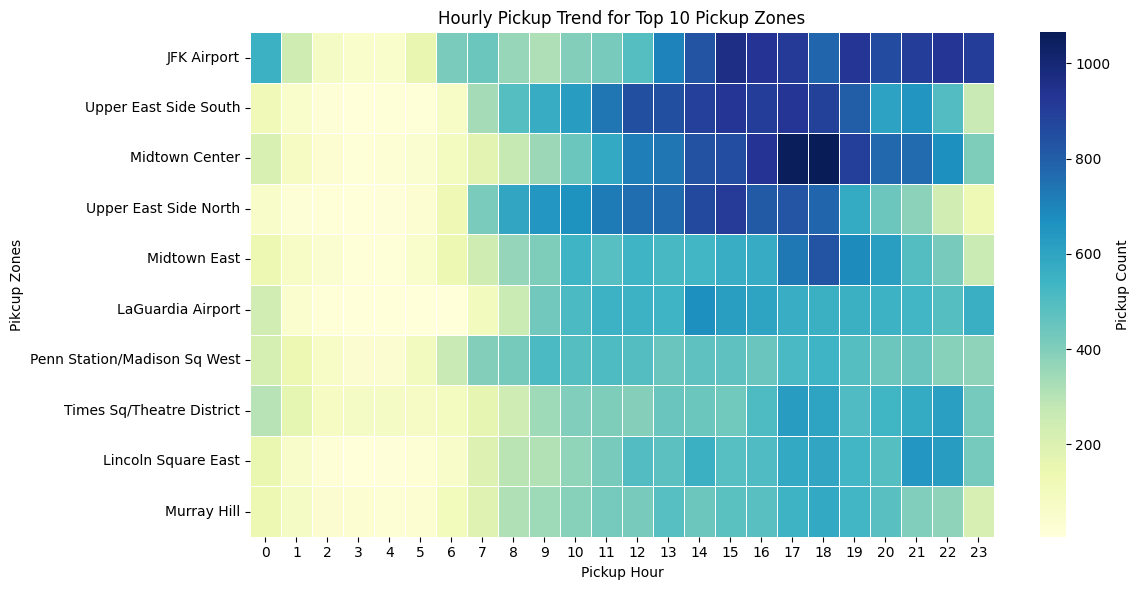

In [191]:
# Visualize Hourly pickup trend for top 10 pickup_zones

plt.figure(figsize=(12, 6))

sns.heatmap(
    pickup_zone_heatmap_data,
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Pickup Count'}
)

plt.title('Hourly Pickup Trend for Top 10 Pickup Zones')
plt.xlabel('Pickup Hour')
plt.ylabel('Pikcup Zones')
plt.tight_layout()
plt.show()

In [192]:
# Identify Top 10 dropoff zones

dropff_zone_volumn = (
    zone_hourly_df
    .groupby('dropoff_zone').size()
    .reset_index(name='total_dropoffs')
    .sort_values('total_dropoffs', ascending=False)
    .reset_index(drop=True)
)

dropff_zone_volumn.head(10)

,dropoff_zone,total_dropoffs
0,Upper East Side North,11470
1,Upper East Side South,10747
2,Midtown Center,10022
3,Times Sq/Theatre District,7794
4,Murray Hill,7627
5,Midtown East,7310
6,Lincoln Square East,7262
7,Upper West Side South,7161
8,Lenox Hill West,6643
9,East Chelsea,6559


In [193]:
# Store top 10 dropoff zone names
top_ten_dropoff_zone_names = dropff_zone_volumn.head(10)['dropoff_zone'].to_list()

In [194]:
# Analyze hourly dropoff trend for top 10 dropoff zones

dropoff_zone_hourly = (
    zone_hourly_df[
        zone_hourly_df['dropoff_zone'].isin(top_ten_dropoff_zone_names)
    ].groupby(['dropoff_zone', 'dropoff_hour'])
    .size()
    .reset_index(name='dropoff_count')
)

In [195]:
# Transform table according to Heatmap chart

dropoff_heatmap_data = (
    dropoff_zone_hourly.pivot_table(
        index='dropoff_zone',
        columns='dropoff_hour',
        values='dropoff_count',
        aggfunc='sum',
        fill_value=0
    )
    .reindex(top_ten_dropoff_zone_names)
    .reindex(columns=range(0, 24), fill_value=0)
)

dropoff_heatmap_data.head()

dropoff_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
dropoff_zone,,,,,,,,,,,,,,,,,,,,,
Upper East Side North,170,102,56,28,23,17,61,262,438,557,...,773,922,843,832,866,712,618,617,510,334
Upper East Side South,115,68,34,16,9,30,89,235,422,550,...,818,791,779,780,849,697,472,458,394,226
Midtown Center,104,47,29,20,15,63,225,499,678,686,...,684,630,649,674,609,489,350,334,289,174
Times Sq/Theatre District,184,100,50,39,42,25,121,248,260,291,...,503,451,513,559,755,612,419,363,339,245
Murray Hill,222,171,107,67,30,19,71,191,303,400,...,429,471,465,495,497,467,439,462,421,314


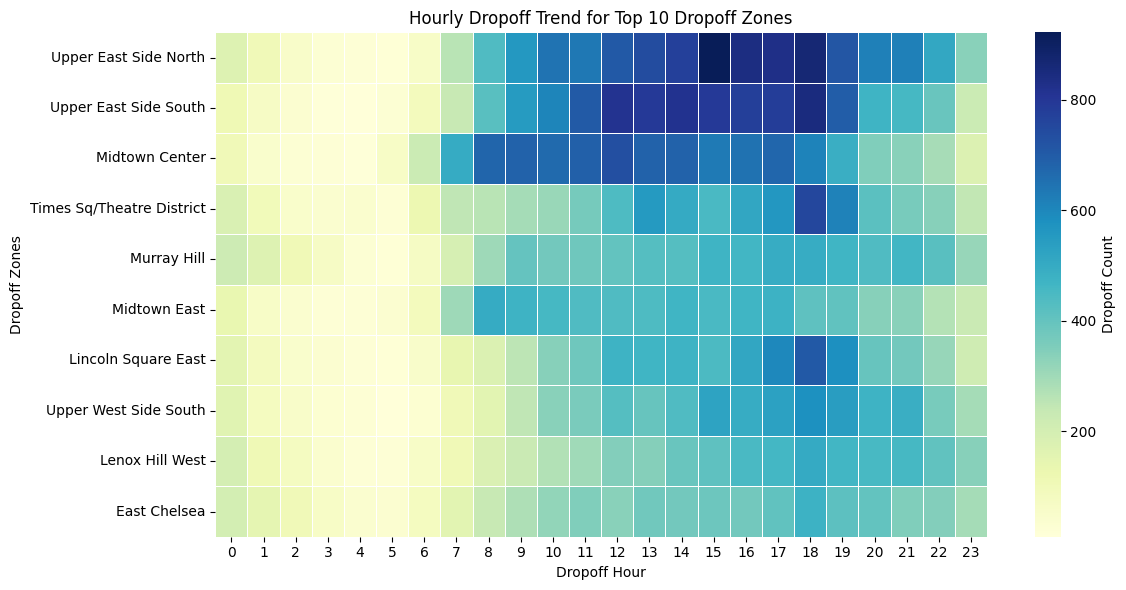

In [196]:
# Visualize Hourly dropoff trend for top 10 dropoff_zones

plt.figure(figsize=(12, 6))

sns.heatmap(
    dropoff_heatmap_data,
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Dropoff Count'}
)

plt.title('Hourly Dropoff Trend for Top 10 Dropoff Zones')
plt.xlabel('Dropoff Hour')
plt.ylabel('Dropoff Zones')

plt.tight_layout()
plt.show()

In [197]:
# Analysis Interpretation
pick_top_ten_pickup_zone = pickup_zone_volumn.head(10)
pick_top_ten_dropoff_zone = dropff_zone_volumn.head(10)

top_pikcup_zone = pick_top_ten_pickup_zone.loc[0, 'pickup_zone']
top_pickup_count = int(pick_top_ten_pickup_zone.loc[0, 'total_pickups'])

top_dropoff_zone = pick_top_ten_dropoff_zone.loc[0, 'dropoff_zone']
top_dropoff_count = int(pick_top_ten_dropoff_zone.loc[0, 'total_dropoffs'])

# Peak Hour among top 10 pickup zones
top_pickup_peak_hour = (pickup_zone_hourly
                        .groupby('pickup_hour')['pickup_count']
                        .sum()
                        .idxmax())

# Peak Hour among top 10 dropoff zones
top_dropoff_peak_hour = (
    dropoff_zone_hourly
    .groupby('dropoff_hour')['dropoff_count']
    .sum()
    .idxmax())

print(f"""
The Top 10 Highest pickup zone is {top_pikcup_zone} with {top_pickup_count:,} trips.
among the top 10 pickup zones, the peak hour is {int(top_pickup_peak_hour)}:00.

The Top 10 Highest dropoff zone is {top_dropoff_zone} with {top_dropoff_count:,} trips.
among the top 10 dropoff zones, the peak hour is {int(top_dropoff_peak_hour)}:00.
""")


The Top 10 Highest pickup zone is JFK Airport with 13,612 trips.
among the top 10 pickup zones, the peak hour is 17:00.

The Top 10 Highest dropoff zone is Upper East Side North with 11,470 trips.
among the top 10 dropoff zones, the peak hour is 18:00.



**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [198]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

# Merge picup and dropoff volume by zone

zone_ratio_df = pickup_zone_volumn.merge(dropff_zone_volumn,
                                         left_on='pickup_zone',
                                         right_on='dropoff_zone',
                                         how='outer')


# create one comm zone column
zone_ratio_df['zone'] = zone_ratio_df['pickup_zone'].combine_first(
    zone_ratio_df['dropoff_zone']
  )

# Impute Missing value by pickup/dropoff counts
zone_ratio_df['total_pickups'] = (zone_ratio_df['total_pickups']
                                  .fillna(0)
                                  .astype(int))

zone_ratio_df['total_dropoffs'] = (zone_ratio_df['total_dropoffs']
                                   .fillna(0)
                                   .astype(int))

# Filter DataSet
zone_ratio_df = zone_ratio_df[['zone', 'total_pickups', 'total_dropoffs']].copy()

# Caluclate total activity
zone_ratio_df['total_activity'] = (zone_ratio_df['total_pickups'] +
                                    zone_ratio_df['total_dropoffs'])

zone_ratio_df.head()

,zone,total_pickups,total_dropoffs,total_activity
0,Allerton/Pelham Gardens,1,10,11
1,Alphabet City,241,919,1160
2,Arden Heights,0,2,2
3,Arrochar/Fort Wadsworth,3,4,7
4,Astoria,107,717,824


In [199]:
# Calculate Ratio: (pickup/dropoff)

zone_ratio_df['pickup_dropoff_ratio'] = np.where(
    zone_ratio_df['total_dropoffs'] > 0,
    zone_ratio_df['total_pickups'] / zone_ratio_df['total_dropoffs'],
    np.nan
)

zone_ratio_df.head()

,zone,total_pickups,total_dropoffs,total_activity,pickup_dropoff_ratio
0,Allerton/Pelham Gardens,1,10,11,0.100000
1,Alphabet City,241,919,1160,0.262242
2,Arden Heights,0,2,2,0.000000
3,Arrochar/Fort Wadsworth,3,4,7,0.750000
4,Astoria,107,717,824,0.149233


In [200]:
# Filter valid zones using total-activity threshold

zone_ratio_filter_df = zone_ratio_df[
    (zone_ratio_df['total_pickups'] > 0) &
    (zone_ratio_df['total_dropoffs'] > 0) &
    (zone_ratio_df['pickup_dropoff_ratio'].notna())
].copy()

In [201]:
print(f"Reliable zones: {zone_ratio_filter_df.shape[0]}")

Reliable zones: 212


In [202]:
# Top 10 pickup-heavy zones: more pickup compares to dropoffs

top_ten_pickup_heavy_zones = (
    zone_ratio_filter_df
    .sort_values('pickup_dropoff_ratio', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Top 10 dropoff-heavy zones:more dropffs compares to pickups

top_ten_dropoff_heavy_zones = (
    zone_ratio_filter_df
    .sort_values('pickup_dropoff_ratio', ascending=True)
    .head(10)
    .reset_index(drop=True)
)

print("Top 10 pickup-heavy zones")
display(top_ten_pickup_heavy_zones)

print("-----------------------------------------------------------------------")

print("Top 10 dropoff-heavy zones")
display(top_ten_dropoff_heavy_zones)

Top 10 pickup-heavy zones


,zone,total_pickups,total_dropoffs,total_activity,pickup_dropoff_ratio
0,East Elmhurst,1181,144,1325,8.201389
1,JFK Airport,13612,2886,16498,4.716563
2,LaGuardia Airport,8987,3089,12076,2.909356
3,Penn Station/Madison Sq West,8746,5774,14520,1.514721
4,Central Park,4387,3146,7533,1.394469
5,West Village,5724,4190,9914,1.366110
6,Greenwich Village South,3338,2485,5823,1.343260
7,Midtown East,9284,7310,16594,1.270041
8,Midtown Center,12024,10022,22046,1.199761
9,Garment District,4193,3524,7717,1.189841


-----------------------------------------------------------------------
Top 10 dropoff-heavy zones


,zone,total_pickups,total_dropoffs,total_activity,pickup_dropoff_ratio
0,East Concourse/Concourse Village,1,71,72,0.014085
1,Howard Beach,1,56,57,0.017857
2,Windsor Terrace,2,108,110,0.018519
3,Rego Park,2,88,90,0.022727
4,East Flatbush/Farragut,1,44,45,0.022727
5,Flushing,4,168,172,0.023810
6,Ridgewood,3,124,127,0.024194
7,Stuyvesant Heights,5,206,211,0.024272
8,Sheepshead Bay,1,41,42,0.024390
9,Murray Hill-Queens,1,40,41,0.025000


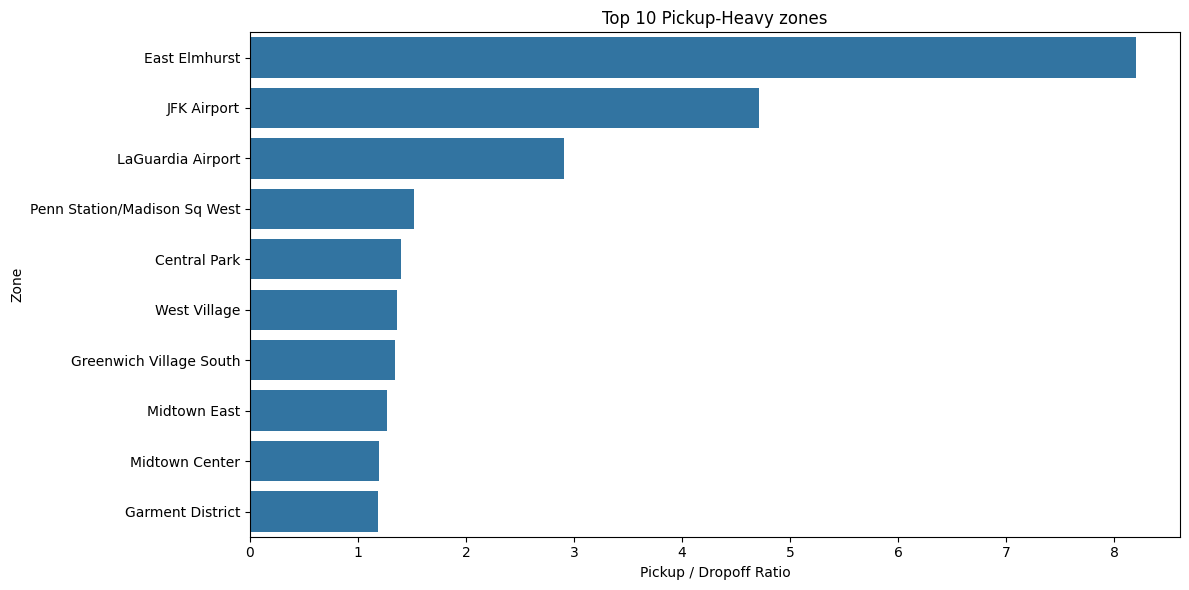

In [203]:
# Visualize top pickup-heavy zones

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_ten_pickup_heavy_zones,
    x='pickup_dropoff_ratio',
    y='zone'
)

plt.title('Top 10 Pickup-Heavy zones')
plt.xlabel('Pickup / Dropoff Ratio')
plt.ylabel('Zone')

plt.tight_layout()
plt.show()

In [204]:
top_ten_dropoff_heavy_zones['dropoff_pickup_ratio'] = (
    top_ten_dropoff_heavy_zones['total_dropoffs'] /
    top_ten_dropoff_heavy_zones['total_pickups']
)

top_ten_dropoff_heavy_zones.head()

,zone,total_pickups,total_dropoffs,total_activity,pickup_dropoff_ratio,dropoff_pickup_ratio
0,East Concourse/Concourse Village,1,71,72,0.014085,71.0
1,Howard Beach,1,56,57,0.017857,56.0
2,Windsor Terrace,2,108,110,0.018519,54.0
3,Rego Park,2,88,90,0.022727,44.0
4,East Flatbush/Farragut,1,44,45,0.022727,44.0


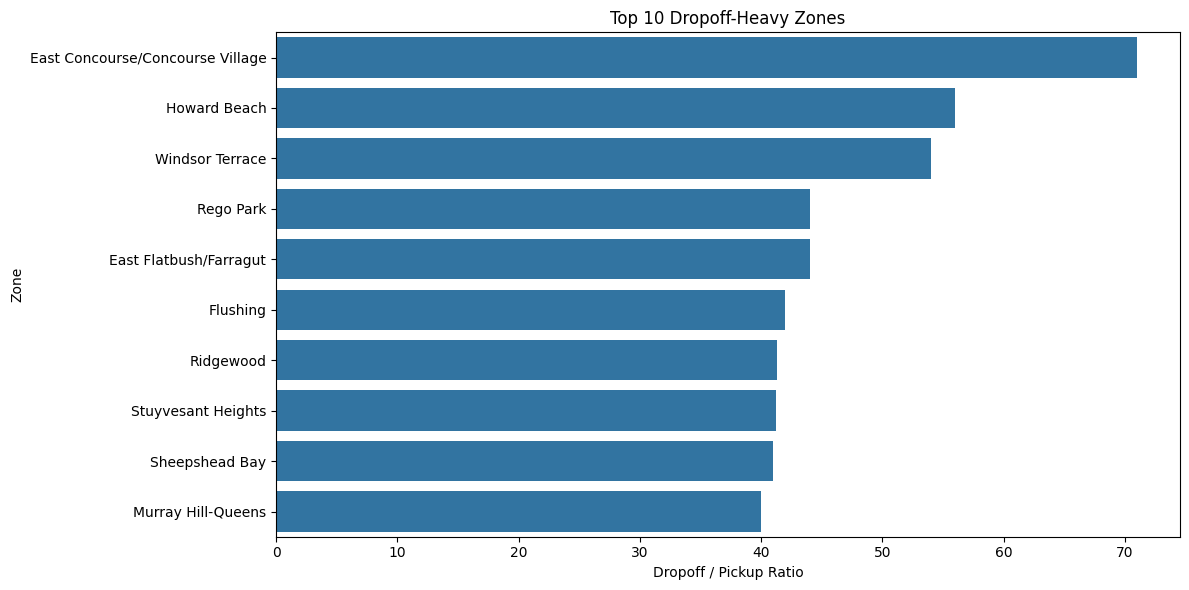

In [205]:
# Visualize top dropoff-heavy zones

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_ten_dropoff_heavy_zones,
    x='dropoff_pickup_ratio',
    y='zone'
)

plt.title('Top 10 Dropoff-Heavy Zones')
plt.xlabel('Dropoff / Pickup Ratio')
plt.ylabel('Zone')

plt.tight_layout()
plt.show()

In [206]:
# Analysis Interpretation

highest_pickup_ratio_zone = top_ten_pickup_heavy_zones.loc[0, 'zone']
highest_pickup_ratio = top_ten_pickup_heavy_zones.loc[0, 'pickup_dropoff_ratio']

highest_dropoff_ratio_zone = top_ten_dropoff_heavy_zones.loc[0, 'zone']
highest_dropoff_ratio = top_ten_dropoff_heavy_zones.loc[0, 'dropoff_pickup_ratio']

print(f"""
{highest_pickup_ratio_zone} has the highest pickup/dropoff ratio of {highest_pickup_ratio:.2f}, making it a pickup-heavy zone.

{highest_dropoff_ratio_zone} has the highest dropoff/pickup ratio of {highest_dropoff_ratio:.2f}, making it a dropoff-heavy zone.
""")


East Elmhurst has the highest pickup/dropoff ratio of 8.20, making it a pickup-heavy zone.

East Concourse/Concourse Village has the highest dropoff/pickup ratio of 71.00, making it a dropoff-heavy zone.



**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [207]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# Define night-hours(11pm to 5am)
night_hrs = [23, 0, 1, 2, 3, 4, 5]

# Filter pickup-trips happend during night
night_pickup_df = zone_hourly_df[
    zone_hourly_df['pickup_hour'].isin(night_hrs)
].copy()


night_pickup_df.head()

,PULocationID,pickup_zone,pickup_borough,DOLocationID,dropoff_zone,dropoff_borough,pickup_hour,tpep_dropoff_datetime,dropoff_hour
0,142,Lincoln Square East,Manhattan,142,Lincoln Square East,Manhattan,0,2023-09-01 00:27:19,0
1,132,JFK Airport,Queens,163,Midtown North,Manhattan,0,2023-09-01 01:04:02,1
2,249,West Village,Manhattan,180,Ozone Park,Queens,0,2023-09-01 01:20:20,1
3,144,Little Italy/NoLiTa,Manhattan,232,Two Bridges/Seward Park,Manhattan,0,2023-09-01 00:17:56,0
4,79,East Village,Manhattan,263,Yorkville West,Manhattan,0,2023-09-01 00:54:33,0


In [208]:
night_pickup_df.shape[0]

30254

In [209]:
# Find Top 10 night hour pickup zones

top_ten_night_pickup_zones = (
    night_pickup_df
    .groupby('pickup_zone')
    .size()
    .reset_index(name='night_pickups')
    .sort_values('night_pickups', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(top_ten_night_pickup_zones)

,pickup_zone,night_pickups
0,East Village,2192
1,JFK Airport,2035
2,West Village,1775
3,Clinton East,1440
4,Lower East Side,1372
5,Times Sq/Theatre District,1210
6,Greenwich Village South,1182
7,Penn Station/Madison Sq West,973
8,LaGuardia Airport,885
9,Midtown South,851


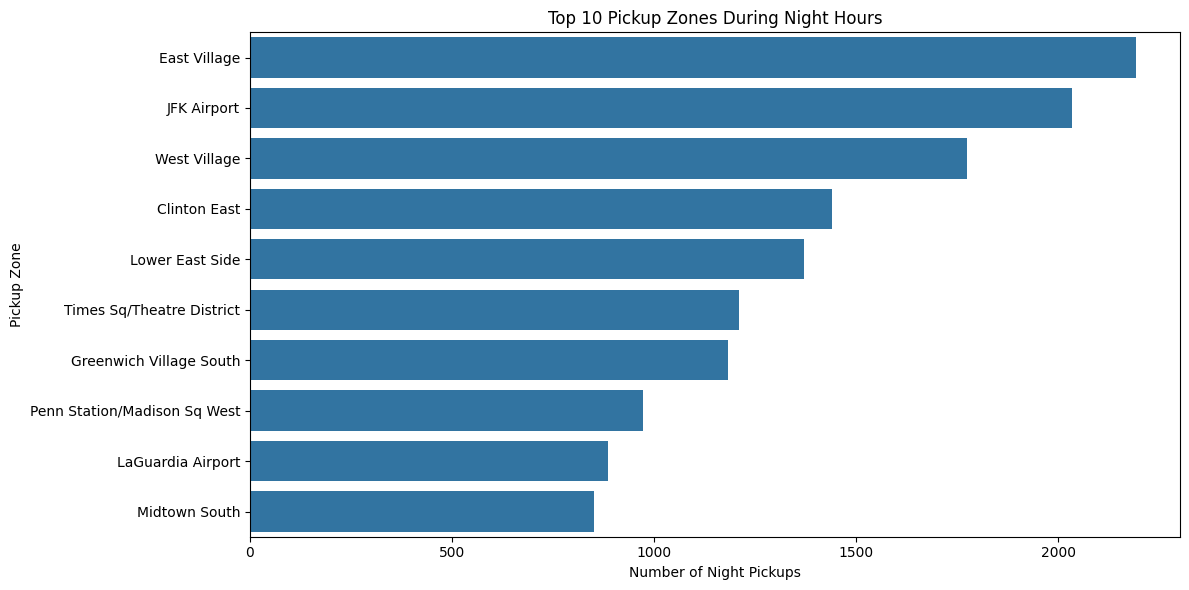

In [210]:
# Visualize top 10 night pickup zones

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_ten_night_pickup_zones,
    x='night_pickups',
    y='pickup_zone'
)

plt.title('Top 10 Pickup Zones During Night Hours')
plt.xlabel('Number of Night Pickups')
plt.ylabel('Pickup Zone')

plt.tight_layout()
plt.show()

In [211]:
# Filter location where dropoff happend at night hours

night_hours_dropoff_df = zone_hourly_df[
    zone_hourly_df['dropoff_hour'].isin(night_hrs)
].copy()

night_hours_dropoff_df.head()

,PULocationID,pickup_zone,pickup_borough,DOLocationID,dropoff_zone,dropoff_borough,pickup_hour,tpep_dropoff_datetime,dropoff_hour
0,142,Lincoln Square East,Manhattan,142,Lincoln Square East,Manhattan,0,2023-09-01 00:27:19,0
1,132,JFK Airport,Queens,163,Midtown North,Manhattan,0,2023-09-01 01:04:02,1
2,249,West Village,Manhattan,180,Ozone Park,Queens,0,2023-09-01 01:20:20,1
3,144,Little Italy/NoLiTa,Manhattan,232,Two Bridges/Seward Park,Manhattan,0,2023-09-01 00:17:56,0
4,79,East Village,Manhattan,263,Yorkville West,Manhattan,0,2023-09-01 00:54:33,0


In [212]:
night_hours_dropoff_df.shape[0]

32986

In [213]:
# Find Top 10 night hour dropoff zones

top_ten_night_dropoff_zones = (
    night_hours_dropoff_df
    .groupby('dropoff_zone')
    .size()
    .reset_index(name='night_dropoffs')
    .sort_values('night_dropoffs', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(top_ten_night_dropoff_zones)

,dropoff_zone,night_dropoffs
0,East Village,1257
1,Clinton East,1054
2,Murray Hill,930
3,East Chelsea,891
4,Gramercy,874
5,Lenox Hill West,813
6,Yorkville West,792
7,Upper East Side North,730
8,West Village,722
9,Times Sq/Theatre District,685


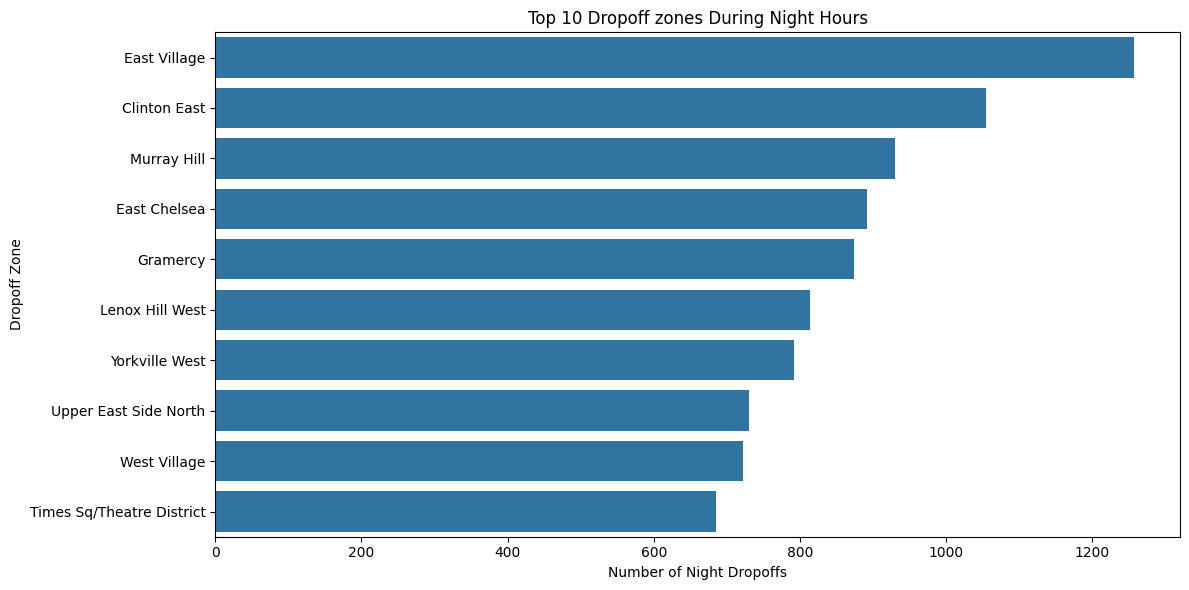

In [214]:
# Visualize top 10 night hours dropoff

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_ten_night_dropoff_zones,
    x='night_dropoffs',
    y='dropoff_zone'
)

plt.title('Top 10 Dropoff zones During Night Hours')
plt.xlabel('Number of Night Dropoffs')
plt.ylabel('Dropoff Zone')

plt.tight_layout()
plt.show()

In [215]:
# Analysis Interpretation

top_night_pickup_zone = top_ten_night_pickup_zones.loc[0, 'pickup_zone']
top_night_pickup_count = int(top_ten_night_pickup_zones.loc[0, 'night_pickups'])

top_night_dropoff_zone = top_ten_night_dropoff_zones.loc[0, 'dropoff_zone']
top_night_dropoff_count = int(top_ten_night_dropoff_zones.loc[0, 'night_dropoffs'])

print(f"""
{top_night_pickup_zone} has the highest number of night pickups with {top_night_pickup_count:,} trips.

{top_night_dropoff_zone} has the highest number of night dropoffs with {top_night_dropoff_count:,} trips.
""")


East Village has the highest number of night pickups with 2,192 trips.

East Village has the highest number of night dropoffs with 1,257 trips.



Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [216]:
# Filter for night hours (11 PM to 5 AM)

revenue_time_df = df[
    (df['total_amount'] > 0) &
    (df['pickup_hour'].notna())
][['pickup_hour', 'total_amount']].copy()

revenue_time_df.head()

,pickup_hour,total_amount
1,0,10.10
2,0,98.40
3,0,64.70
4,0,14.90
5,0,28.92


In [217]:
revenue_time_df['time_period'] = np.where(
    revenue_time_df['pickup_hour'].isin(night_hrs),
    'Night',
    'Day'
)

revenue_time_df.head()

,pickup_hour,total_amount,time_period
1,0,10.10,Night
2,0,98.40,Night
3,0,64.70,Night
4,0,14.90,Night
5,0,28.92,Night


In [218]:
# Calculate revenue share for night and day time period.

revenue_by_time = (revenue_time_df.groupby('time_period')['total_amount']
                   .sum()
                   .reset_index())

# Rename column to related to business logic
revenue_by_time = revenue_by_time.rename(columns={'total_amount': 'total_revenue'})

revenue_by_time

,time_period,total_revenue
0,Day,6452242.71
1,Night,894072.27


In [219]:
# Calculate revenue by percentage
total_revenue = revenue_by_time['total_revenue'].sum()

revenue_by_time['revenue_share_percentage'] = (
    revenue_by_time['total_revenue'] / total_revenue * 100
).round(2)

revenue_by_time

,time_period,total_revenue,revenue_share_percentage
0,Day,6452242.71,87.83
1,Night,894072.27,12.17


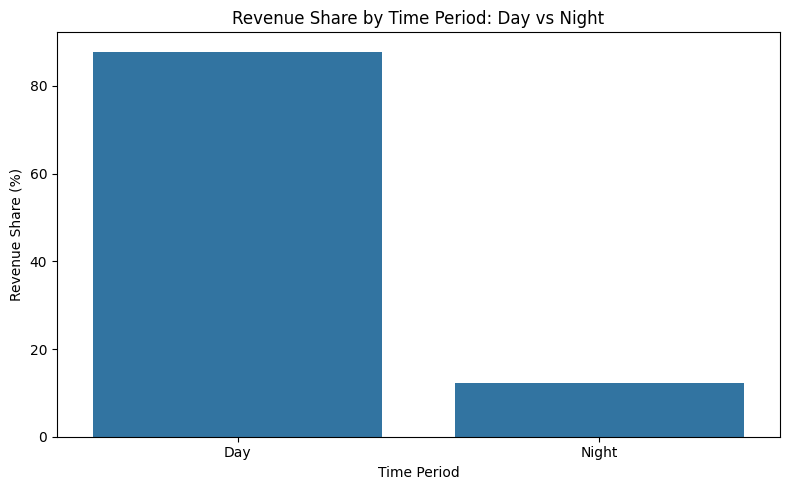

In [220]:
# Visualize revenue by Time Period

plt.figure(figsize=(8, 5))

sns.barplot(
    data=revenue_by_time,
    x='time_period',
    y='revenue_share_percentage'
)

plt.title('Revenue Share by Time Period: Day vs Night')
plt.xlabel('Time Period')
plt.ylabel('Revenue Share (%)')

plt.tight_layout()
plt.show()

In [221]:
# Analysis Interpretation

day_revenue = revenue_by_time.loc[revenue_by_time['time_period'] == 'Day', 'revenue_share_percentage'].iloc[0]
night_revenue = revenue_by_time.loc[revenue_by_time['time_period'] == 'Night', 'revenue_share_percentage'].iloc[0]

print(f"""
Day-Time trips contribute {day_revenue:.2f}% of total revenue.
Night-Time trips contribute {night_revenue:.2f}% of total revenue.

This Result showcase that most of the taxi revenue comes from day-time period.
""")


Day-Time trips contribute 87.83% of total revenue.
Night-Time trips contribute 12.17% of total revenue.

This Result showcase that most of the taxi revenue comes from day-time period.



##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [222]:
# Analyse the fare per mile per passenger for different passenger counts


fare_passenger_df = df[
    (df['fare_amount'] > 0) &
    (df['trip_distance'] > 0) &
    (df['passenger_count'] > 0)
][['fare_amount', 'trip_distance', 'passenger_count']].copy()

fare_passenger_df.head()

,fare_amount,trip_distance,passenger_count
1,5.1,0.56,2
2,70.0,18.46,2
3,59.7,13.71,2
4,7.9,0.71,1
5,19.1,4.39,5


In [223]:
# Calculate fare per mile
fare_passenger_df['fare_per_mile'] = (
    fare_passenger_df['fare_amount'] / fare_passenger_df['trip_distance']
)

# Calculate Avg. fare mile for each passanger count
avg_fare_per_mile = (
    fare_passenger_df
    .groupby('passenger_count')['fare_per_mile']
    .mean()
    .reset_index()
)

# Rename colume name as per business logic
avg_fare_per_mile = avg_fare_per_mile.rename(
    columns={'fare_per_mile': 'avg_fare_per_mile'
    })

# Calculate fare per mile per passenger
avg_fare_per_mile['fare_per_mile_per_passenger'] = (
    avg_fare_per_mile['avg_fare_per_mile'] / avg_fare_per_mile['passenger_count']
)

avg_fare_per_mile.head()

,passenger_count,avg_fare_per_mile,fare_per_mile_per_passenger
0,1,10.726601,10.726601
1,2,12.370998,6.185499
2,3,12.997215,4.332405
3,4,20.729736,5.182434
4,5,7.826500,1.565300


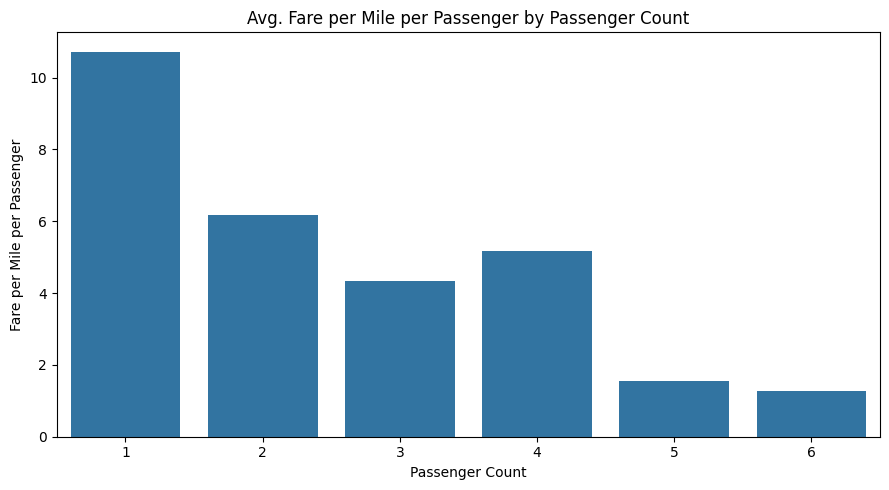

In [224]:
# Visualize fare per mile per passanger by passenger count

plt.figure(figsize=(9, 5))

sns.barplot(
    data=avg_fare_per_mile,
    x='passenger_count',
    y='fare_per_mile_per_passenger'
)

plt.title('Avg. Fare per Mile per Passenger by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare per Mile per Passenger')

plt.tight_layout()
plt.show()

In [225]:
# Analysis Interpretation
lowest_value = avg_fare_per_mile.sort_values('fare_per_mile_per_passenger').iloc[0]
highest_value = avg_fare_per_mile.sort_values(
    'fare_per_mile_per_passenger', ascending=False).iloc[0]


print(f"""
  Passenger count {int(highest_value['passenger_count'])} has the highest fare per mile per passenger at {highest_value['fare_per_mile_per_passenger']:.2f}.
  Passenger count {int(lowest_value['passenger_count'])} has the lowest fare per mile per passenger at {lowest_value['fare_per_mile_per_passenger']:.2f}.
""")


  Passenger count 1 has the highest fare per mile per passenger at 10.73.
  Passenger count 6 has the lowest fare per mile per passenger at 1.29.



**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [226]:
# Compare the average fare per mile for different days and for different times of the day

fare_time_df = df[
    (df['fare_amount'] > 0) &
    (df['trip_distance'] > 0) &
    (df['pickup_hour'].notna()) &
    (df['pickup_day'].notna())
][['fare_amount', 'trip_distance', 'pickup_hour', 'pickup_day']].copy()

fare_time_df.head(5)

,fare_amount,trip_distance,pickup_hour,pickup_day
1,5.1,0.56,0,Friday
2,70.0,18.46,0,Friday
3,59.7,13.71,0,Friday
4,7.9,0.71,0,Friday
5,19.1,4.39,0,Friday


In [227]:
# Calculate fare per mile

fare_time_df['fare_per_mile'] = (fare_time_df['fare_amount'] /
                                 fare_time_df['trip_distance'])

fare_time_df.head()

,fare_amount,trip_distance,pickup_hour,pickup_day,fare_per_mile
1,5.1,0.56,0,Friday,9.107143
2,70.0,18.46,0,Friday,3.791983
3,59.7,13.71,0,Friday,4.354486
4,7.9,0.71,0,Friday,11.126761
5,19.1,4.39,0,Friday,4.350797


In [228]:
# Avg. fare per mile by pickup location

hourly_fare_per_mile = (
    fare_time_df
    .groupby('pickup_hour')['fare_per_mile']
    .mean()
    .reset_index()
)

# Rename column name as per Business logic
hourly_fare_per_mile = hourly_fare_per_mile.rename(
    columns={'fare_per_mile': 'avg_fare_per_mile'}
)

hourly_fare_per_mile.head()


,pickup_hour,avg_fare_per_mile
0,0,11.833131
1,1,15.656581
2,2,9.039845
3,3,9.584646
4,4,19.111467


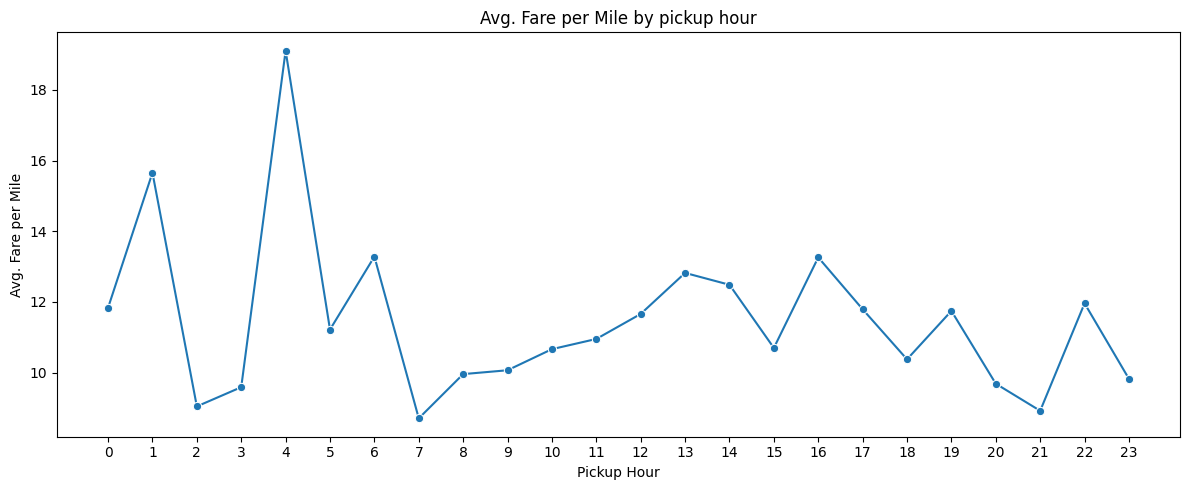

In [229]:
# Visualise avg. fare per mile by pickup hour

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_fare_per_mile,
    x='pickup_hour',
    y='avg_fare_per_mile',
    marker='o'
)

plt.title('Avg. Fare per Mile by pickup hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Avg. Fare per Mile')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [230]:
daily_fare_per_mile = (
    fare_time_df
    .groupby('pickup_day')['fare_per_mile']
    .mean()
    .reset_index()
)

daily_fare_per_mile = daily_fare_per_mile.rename(
    columns={'fare_per_mile': 'avg_fare_per_mile'}
)

daily_fare_per_mile.head()

,pickup_day,avg_fare_per_mile
0,Friday,9.853485
1,Monday,10.203419
2,Saturday,11.134886
3,Sunday,11.677437
4,Thursday,12.785762


In [231]:
# Sort by Day Order

daily_fare_per_mile['pickup_day'] = pd.Categorical(
    daily_fare_per_mile['pickup_day'],
    categories=day_order,
    ordered=True
)

daily_fare_per_mile = daily_fare_per_mile.sort_values('pickup_day')

daily_fare_per_mile.head()

,pickup_day,avg_fare_per_mile
1,Monday,10.203419
5,Tuesday,10.901929
6,Wednesday,11.668089
4,Thursday,12.785762
0,Friday,9.853485


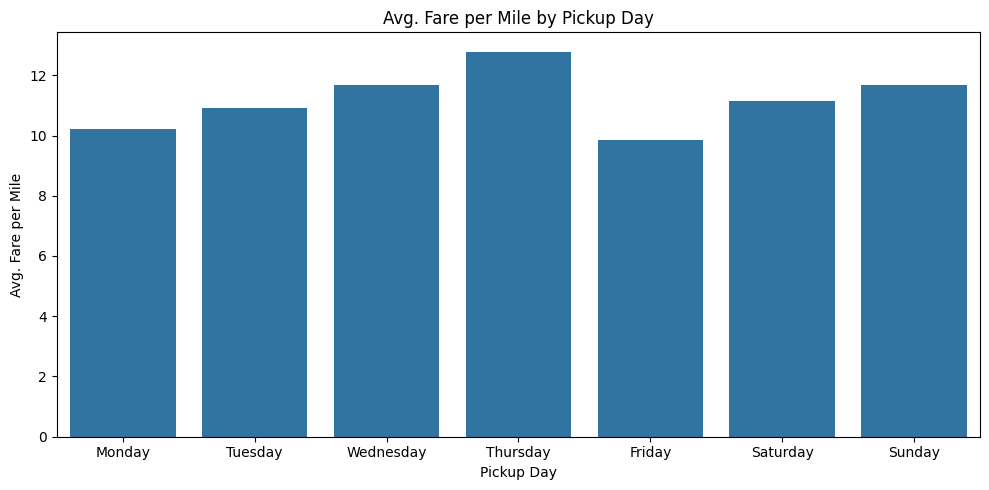

In [232]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=daily_fare_per_mile,
    x='pickup_day',
    y='avg_fare_per_mile'
)

plt.title('Avg. Fare per Mile by Pickup Day')
plt.xlabel('Pickup Day')
plt.ylabel('Avg. Fare per Mile')

plt.tight_layout()
plt.show()

In [233]:
# Analysis Interpretation

highest_hour = hourly_fare_per_mile.sort_values(
    'avg_fare_per_mile', ascending=False
).iloc[0]

highest_day = daily_fare_per_mile.sort_values(
    'avg_fare_per_mile', ascending=False
).iloc[0]

print(f"""
The highest average fare per mile at {int(highest_hour['pickup_hour'])}:00.

The highest average fare by date at {highest_day['pickup_day']}.
""")


The highest average fare per mile at 4:00.

The highest average fare by date at Thursday.



**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [234]:
# Compare fare per mile for different vendors

vendor_hour_df = df[
    (df['fare_amount'] > 0) &
    (df['trip_distance'] > 0) &
    (df['VendorID'].notna()) &
    (df['pickup_hour'].notna())
][['VendorID', 'fare_amount', 'trip_distance', 'pickup_hour']].copy()

vendor_hour_df.head()

,VendorID,fare_amount,trip_distance,pickup_hour
1,2,5.1,0.56,0
2,2,70.0,18.46,0
3,2,59.7,13.71,0
4,2,7.9,0.71,0
5,2,19.1,4.39,0


In [235]:
# Calculate Fare per Mile

vendor_hour_df['fare_per_mile'] = (
    vendor_hour_df['fare_amount'] / vendor_hour_df['trip_distance']
)

# Map VendorID to Vendor Names
vendor_mapping = {
    1: 'Creative Mobile Technologies',
    2: 'VeriFone'
}

vendor_hour_df['vendor_name'] = vendor_hour_df['VendorID'].map(vendor_mapping)

vendor_hour_df.head()

,VendorID,fare_amount,trip_distance,pickup_hour,fare_per_mile,vendor_name
1,2,5.1,0.56,0,9.107143,VeriFone
2,2,70.0,18.46,0,3.791983,VeriFone
3,2,59.7,13.71,0,4.354486,VeriFone
4,2,7.9,0.71,0,11.126761,VeriFone
5,2,19.1,4.39,0,4.350797,VeriFone


In [236]:
# Calculate average fare per mile by vendor and pickup hour

vendor_hour_fare = (
    vendor_hour_df
    .groupby(['vendor_name', 'pickup_hour'])['fare_per_mile']
    .mean()
    .reset_index()
)

vendor_hour_fare = vendor_hour_fare.rename(columns={'fare_per_mile': 'avg_fare_per_mile'})

vendor_hour_fare.head()

,vendor_name,pickup_hour,avg_fare_per_mile
0,Creative Mobile Technologies,0,6.569060
1,Creative Mobile Technologies,1,7.208228
2,Creative Mobile Technologies,2,7.186802
3,Creative Mobile Technologies,3,6.431048
4,Creative Mobile Technologies,4,6.234271


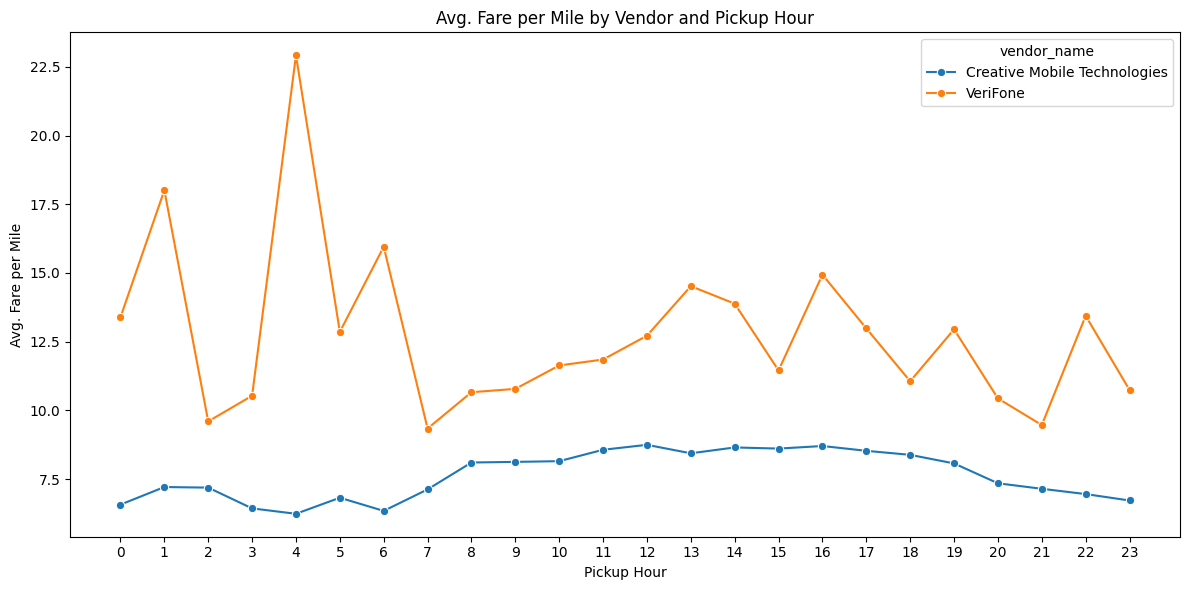

In [237]:
# Visualise average fare per mile by vendor and hour

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=vendor_hour_fare,
    x='pickup_hour',
    y='avg_fare_per_mile',
    hue='vendor_name',
    marker='o'
)

plt.title('Avg. Fare per Mile by Vendor and Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Avg. Fare per Mile')
plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

In [238]:
# Analysis Interpretation

highest_vendor_hour = vendor_hour_fare.sort_values(
    'avg_fare_per_mile', ascending=False
).iloc[0]

print(f"""
{highest_vendor_hour['vendor_name']} has the highest average fare per mile at {int(highest_vendor_hour['pickup_hour'])}

This shows that fare per mile is varies by both vendor and pickup hour.
""")


VeriFone has the highest average fare per mile at 4

This shows that fare per mile is varies by both vendor and pickup hour.



**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [239]:
# Defining distance tiers

vendor_tier_df = df[
    (df['fare_amount'] > 0) &
    (df['trip_distance'] > 0) &
    (df['VendorID'].notna())
][['VendorID', 'fare_amount', 'trip_distance']].copy()

vendor_tier_df.head()

,VendorID,fare_amount,trip_distance
1,2,5.1,0.56
2,2,70.0,18.46
3,2,59.7,13.71
4,2,7.9,0.71
5,2,19.1,4.39


In [240]:
# Calculate fare per mile
vendor_tier_df['fare_per_mile'] = (
    vendor_tier_df['fare_amount'] / vendor_tier_df['trip_distance']
)

# Assign name to respective VendorID
vendor_tier_df['vendor_name'] = vendor_tier_df['VendorID'].map(vendor_mapping)

vendor_tier_df.head()

,VendorID,fare_amount,trip_distance,fare_per_mile,vendor_name
1,2,5.1,0.56,9.107143,VeriFone
2,2,70.0,18.46,3.791983,VeriFone
3,2,59.7,13.71,4.354486,VeriFone
4,2,7.9,0.71,11.126761,VeriFone
5,2,19.1,4.39,4.350797,VeriFone


In [241]:
# Define Distance tiers

vendor_tier_df['distance_tier'] = ''

vendor_tier_df.loc[
    vendor_tier_df['trip_distance'] <= 2,
    'distance_tier'
    ] = 'Up to 2 miles'

vendor_tier_df.loc[
    (vendor_tier_df['trip_distance'] > 2) &
    (vendor_tier_df['trip_distance'] <= 5),
    'distance_tier'
] = 'From 2 to 5 miles'

vendor_tier_df.loc[
    vendor_tier_df['trip_distance'] > 5,
    'distance_tier'
] = 'More than 5 miles'

vendor_tier_df.head()

,VendorID,fare_amount,trip_distance,fare_per_mile,vendor_name,distance_tier
1,2,5.1,0.56,9.107143,VeriFone,Up to 2 miles
2,2,70.0,18.46,3.791983,VeriFone,More than 5 miles
3,2,59.7,13.71,4.354486,VeriFone,More than 5 miles
4,2,7.9,0.71,11.126761,VeriFone,Up to 2 miles
5,2,19.1,4.39,4.350797,VeriFone,From 2 to 5 miles


In [242]:
# Check data distribution between 3 distance tier
vendor_tier_df['distance_tier'].value_counts()

,count
distance_tier,
Up to 2 miles,140335
From 2 to 5 miles,68863
More than 5 miles,42827


In [243]:
# Calculate average fare per mile by vendor and distance tier

vendor_tier_fare = (
    vendor_tier_df
    .groupby(['vendor_name', 'distance_tier'])['fare_per_mile']
    .mean()
    .reset_index()
)

vendor_tier_fare = vendor_tier_fare.rename(columns={'fare_per_mile' : 'avg_fare_per_mile'})

vendor_tier_fare.head(1)

,vendor_name,distance_tier,avg_fare_per_mile
0,Creative Mobile Technologies,From 2 to 5 miles,6.364827


In [244]:
# Sort distance tiers in correct order

distance_tier_order = ['Up to 2 miles', '2 to 5 miles', 'More than 5 miles']

vendor_tier_fare['distance_tier'] = pd.Categorical(
    vendor_tier_fare['distance_tier'],
    categories = distance_tier_order,
    ordered=True
)

vendor_tier_fare = vendor_tier_fare.sort_values(['distance_tier', 'vendor_name'])

vendor_tier_fare.head()

,vendor_name,distance_tier,avg_fare_per_mile
2,Creative Mobile Technologies,Up to 2 miles,9.635515
5,VeriFone,Up to 2 miles,17.780122
1,Creative Mobile Technologies,More than 5 miles,4.448212
4,VeriFone,More than 5 miles,4.500368
0,Creative Mobile Technologies,NaN,6.364827


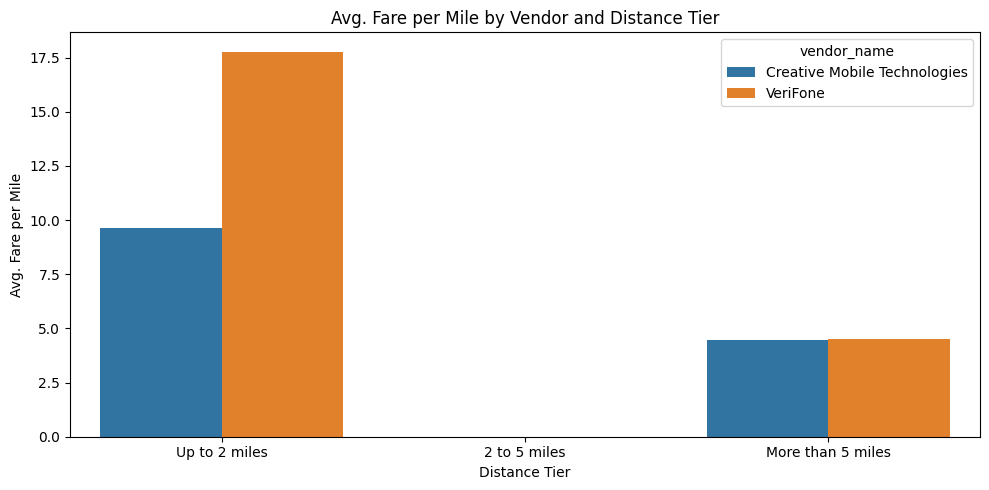

In [245]:
# Visualise average fare per mile by vendor and distance tier

plt.figure(figsize=(10, 5))

sns.barplot(
    data=vendor_tier_fare,
    x='distance_tier',
    y='avg_fare_per_mile',
    hue='vendor_name'
)

plt.title('Avg. Fare per Mile by Vendor and Distance Tier')
plt.xlabel('Distance Tier')
plt.ylabel('Avg. Fare per Mile')

plt.tight_layout()
plt.show()

In [246]:
# Analysis Interpretation

highest_vendor_tier = vendor_tier_fare.sort_values(
    'avg_fare_per_mile', ascending=False
).iloc[0]

print(f"""
'{highest_vendor_tier['vendor_name']}' has the highest avg. fare per mile in the '{highest_vendor_tier['distance_tier']}' distance tier.

This comparison shows how fare rates vary between vendor across short, medium and long-distance trips.
""")


'VeriFone' has the highest avg. fare per mile in the 'Up to 2 miles' distance tier.

This comparison shows how fare rates vary between vendor across short, medium and long-distance trips.



##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [247]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

tip_df = df[
    (df['payment_type'] == 1) &
    (df['tip_amount'] >= 0) &
    (df['total_amount'] > df['tip_amount']) &
    (df['trip_distance'] > 0) &
    (df['passenger_count'] > 0) &
    (df['pickup_hour'].notna())
][['tip_amount', 'total_amount', 'trip_distance', 'passenger_count', 'pickup_hour']].copy()

tip_df.head()

,tip_amount,total_amount,trip_distance,passenger_count,pickup_hour
2,15.71,98.40,18.46,2,0
4,2.00,14.90,0.71,1,0
5,4.82,28.92,4.39,5,0
6,3.42,20.52,1.76,1,0
7,6.22,37.32,6.32,1,0


In [248]:
# Calculate tip percentage

tip_df['pre_tip_amount'] = tip_df['total_amount'] - tip_df['tip_amount']

tip_df['tip_percentage'] = (
    tip_df['tip_amount'] / tip_df['pre_tip_amount'] * 100
)

# For stable analysis remove extreme tip percentage values
tip_df = tip_df[
    (tip_df['tip_percentage'] >= 0) &
    (tip_df['tip_percentage'] <= 60)
].copy()
tip_df.head()

,tip_amount,total_amount,trip_distance,passenger_count,pickup_hour,pre_tip_amount,tip_percentage
2,15.71,98.40,18.46,2,0,82.69,18.998670
4,2.00,14.90,0.71,1,0,12.90,15.503876
5,4.82,28.92,4.39,5,0,24.10,20.000000
6,3.42,20.52,1.76,1,0,17.10,20.000000
7,6.22,37.32,6.32,1,0,31.10,20.000000


In [249]:
# Define Distance tiers

tip_df['distance_tier'] = ''

tip_df.loc[
    tip_df['trip_distance'] <= 2,
    'distance_tier'
    ] = 'Up to 2 miles'

tip_df.loc[
    (tip_df['trip_distance'] > 2) &
    (tip_df['trip_distance'] <= 5),
    'distance_tier'
] = 'From 2 to 5 miles'

tip_df.loc[
    tip_df['trip_distance'] > 5,
    'distance_tier'
] = 'More than 5 miles'

tip_df['distance_tier'].value_counts()

,count
distance_tier,
Up to 2 miles,112926
From 2 to 5 miles,57991
More than 5 miles,34592


In [250]:
# Avg. tip percentage by distance tier
tip_by_distance = (
    tip_df.groupby('distance_tier')['tip_percentage']
    .mean()
    .reset_index()
)

# Rename By Business Logic
tip_by_distance = tip_by_distance.rename(columns={'tip_percentage': 'avg_tip_percentage'})


# Sort by tier in correct order
tip_by_distance['distance_tier'] = pd.Categorical(
    tip_by_distance['distance_tier'],
    categories=distance_tier_order,
    ordered=True
)

tip_by_distance = tip_by_distance.sort_values('distance_tier')

tip_by_distance.head()

,distance_tier,avg_tip_percentage
2,Up to 2 miles,18.070438
1,More than 5 miles,17.046921
0,NaN,17.464922


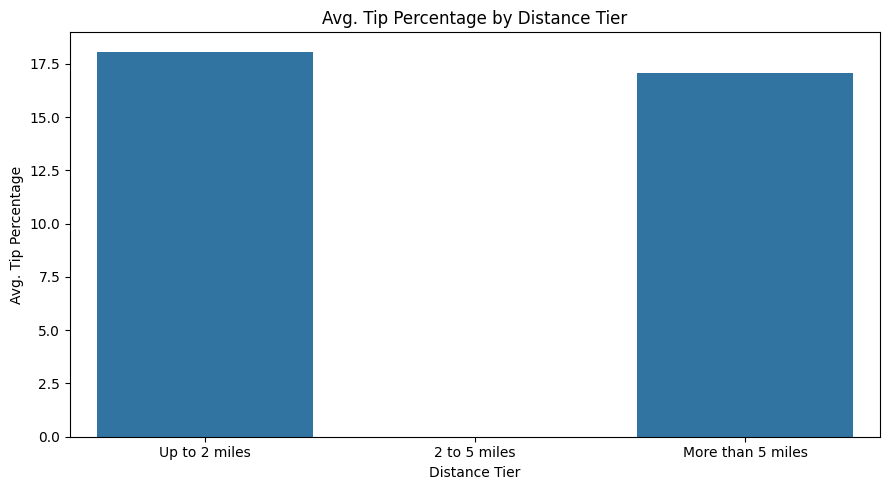

In [251]:
# Visualise avg. tip percentage by distance tier

plt.figure(figsize=(9, 5))

sns.barplot(
    data=tip_by_distance,
    x='distance_tier',
    y='avg_tip_percentage'
)

plt.title('Avg. Tip Percentage by Distance Tier')
plt.xlabel('Distance Tier')
plt.ylabel('Avg. Tip Percentage')

plt.tight_layout()
plt.show()

In [252]:
# Avg. Tip Percentage by passanger count

tip_by_passenger = (
    tip_df.groupby('passenger_count')['tip_percentage']
    .mean()
    .reset_index()
)

tip_by_passenger = tip_by_passenger.rename(columns={'tip_percentage' : 'avg_tip_percentage'})

In [253]:
tip_by_passenger.head(1)

,passenger_count,avg_tip_percentage
0,1,17.766632


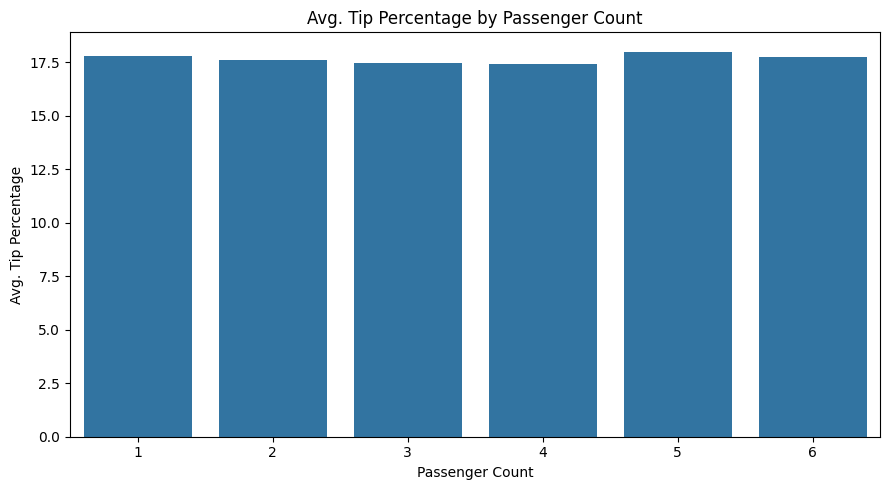

In [254]:
# Visualize Avg. tip percentage by passanger count

plt.figure(figsize=(9, 5))

sns.barplot(
    data=tip_by_passenger,
    x='passenger_count',
    y='avg_tip_percentage'
)

plt.title('Avg. Tip Percentage by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Avg. Tip Percentage')

plt.tight_layout()
plt.show()

In [255]:
# Avg. tip percentage by pickup hour

tip_by_hour = (
    tip_df.groupby('pickup_hour')['tip_percentage']
    .mean().reset_index()
)

tip_by_hour = tip_by_hour.rename(columns={'tip_percentage': 'avg_tip_percentage'})

tip_by_hour.head()

,pickup_hour,avg_tip_percentage
0,0,16.984364
1,1,16.944304
2,2,16.359069
3,3,16.384448
4,4,16.342900


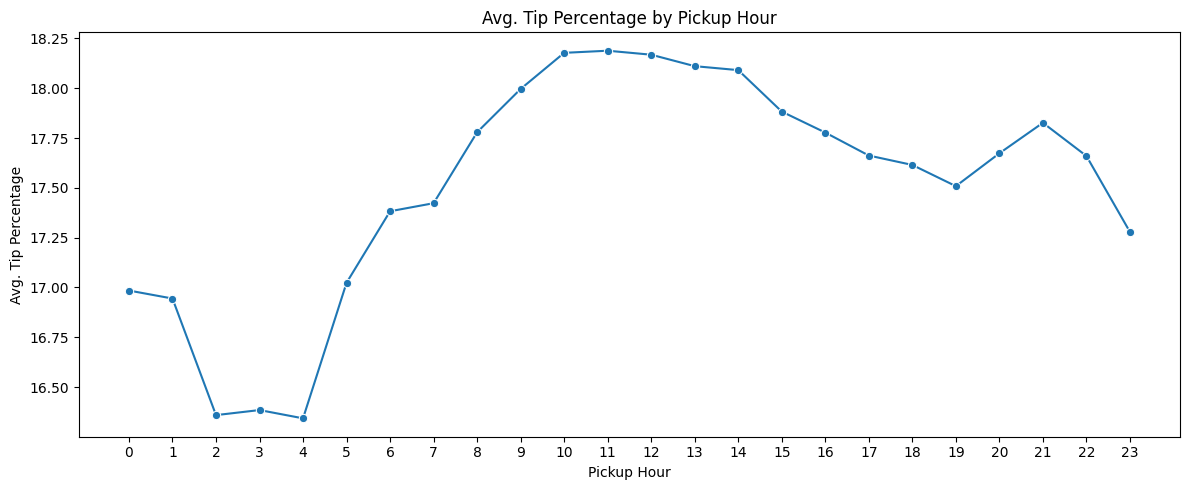

In [256]:
# Visualise avg. tip percentage by pickup hour

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=tip_by_hour,
    x='pickup_hour',
    y='avg_tip_percentage',
    marker='o'
)

plt.title('Avg. Tip Percentage by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Avg. Tip Percentage')
plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

In [257]:
# Find Lowest avg. tip percentage by factors

lowest_dist_tip = tip_by_distance.sort_values('avg_tip_percentage').iloc[0]
lowest_passenger_tip = tip_by_passenger.sort_values('avg_tip_percentage').iloc[0]
lowest_hour_tip = tip_by_hour.sort_values('avg_tip_percentage').iloc[0]

print("Lowest tip distance tier:")
display(lowest_dist_tip)

print()
print("Lowest tip passenger count:")
display(lowest_passenger_tip)

print()
print("Lowest tip pickup hour:")
display(lowest_hour_tip)

Lowest tip distance tier:


,1
distance_tier,More than 5 miles
avg_tip_percentage,17.046921



Lowest tip passenger count:


,3
passenger_count,4.000000
avg_tip_percentage,17.428043



Lowest tip pickup hour:


,4
pickup_hour,4.0000
avg_tip_percentage,16.3429


In [258]:
# Analysis Interpretation

print(f"""
The lowest average tip percentage is observed for {lowest_dist_tip['distance_tier']} trips.

Passenger count {int(lowest_passenger_tip['passenger_count'])} has the lowest average tip percentage.

The lowest average tip percentage by pickup time is observed at {int(lowest_hour_tip['pickup_hour'])}:00.
""")


The lowest average tip percentage is observed for More than 5 miles trips.

Passenger count 4 has the lowest average tip percentage.

The lowest average tip percentage by pickup time is observed at 4:00.



Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [259]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%



**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [260]:
# See how passenger count varies across hours and days

passenger_time_df = df[
    (df['passenger_count'] > 0) &
    (df['passenger_count'] <= 6) &
    (df['pickup_hour'].notna()) &
    (df['pickup_day'].notna())
][['passenger_count', 'pickup_hour', 'pickup_day']].copy()

passenger_time_df.head()

,passenger_count,pickup_hour,pickup_day
1,2,0,Friday
2,2,0,Friday
3,2,0,Friday
4,1,0,Friday
5,5,0,Friday


In [261]:
# Avg. passanger Count by pickup hour

hourly_passenger_count = (
    passenger_time_df.groupby('pickup_hour')['passenger_count']
    .mean()
    .reset_index()
)

# Rename
hourly_passenger_count = hourly_passenger_count.rename(columns={'passenger_count': 'avg_passenger_count'})

hourly_passenger_count.head()

,pickup_hour,avg_passenger_count
0,0,1.406150
1,1,1.456749
2,2,1.428117
3,3,1.428292
4,4,1.353834


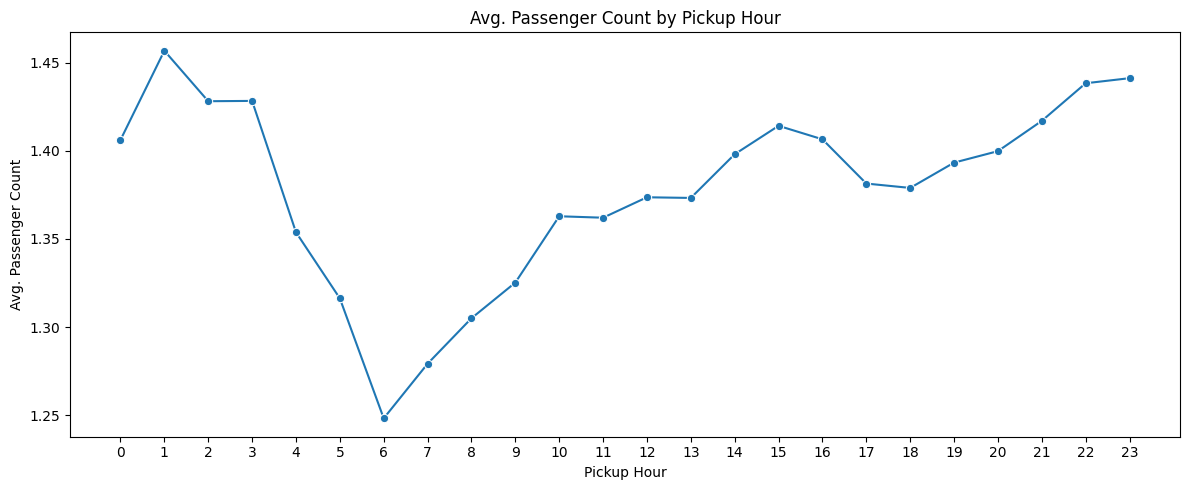

In [262]:
# Visualize avg. passenger count by pickup hour

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_passenger_count,
    x='pickup_hour',
    y='avg_passenger_count',
    marker='o'
)

plt.title('Avg. Passenger Count by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Avg. Passenger Count')
plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

In [263]:
# Avg. passenger count by pickup day
daily_passenger_count = (
    passenger_time_df.groupby('pickup_day')['passenger_count']
    .mean()
    .reset_index()
)

daily_passenger_count = daily_passenger_count.rename(columns={'passenger_count': 'avg_passenger_count'})


# Sort days in correct Weekday order
daily_passenger_count['pickup_day'] = pd.Categorical(
    daily_passenger_count['pickup_day'],
    categories=day_order,
    ordered=True
)

daily_passenger_count = daily_passenger_count.sort_values('pickup_day')

daily_passenger_count.head()

,pickup_day,avg_passenger_count
1,Monday,1.358442
5,Tuesday,1.332097
6,Wednesday,1.331556
4,Thursday,1.341849
0,Friday,1.409687


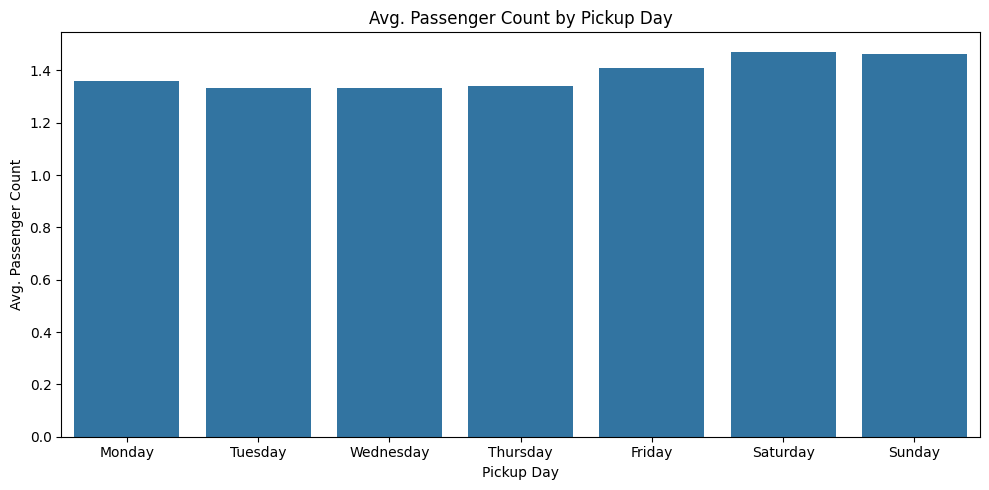

In [264]:
# Visualise avg. passenger count by pickup day

plt.figure(figsize=(10, 5))

sns.barplot(
    data=daily_passenger_count,
    x='pickup_day',
    y='avg_passenger_count'
)

plt.title('Avg. Passenger Count by Pickup Day')
plt.xlabel('Pickup Day')
plt.ylabel('Avg. Passenger Count')

plt.tight_layout()
plt.show()

In [265]:
# Analysis Interpretation

highest_passenger_hour = hourly_passenger_count.sort_values(
    'avg_passenger_count', ascending=False
).iloc[0]

highest_passenger_day = daily_passenger_count.sort_values(
    'avg_passenger_count', ascending=False
).iloc[0]

print(f"""
The highest average passenger count is observed at {int(highest_passenger_hour['pickup_hour'])}:00.

The highest average passenger count is observed on {highest_passenger_day['pickup_day']}.
""")


The highest average passenger count is observed at 1:00.

The highest average passenger count is observed on Saturday.



**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [266]:
# How does passenger count vary across zones

zone_passenger_df = df[
    (df['passenger_count'] > 0) &
    (df['passenger_count'] <= 6) &
    (df['PULocationID'].notna())
][['PULocationID', 'passenger_count']].copy()

zone_passenger_df.head()

,PULocationID,passenger_count
1,142,2
2,132,2
3,249,2
4,144,1
5,79,5


In [267]:
zone_avg_passenger = (
    zone_passenger_df.groupby('PULocationID')['passenger_count']
    .mean()
    .reset_index()
)

zone_avg_passenger = zone_avg_passenger.rename(columns={
    'PULocationID': 'LocationID',
    'passenger_count': 'avg_passenger_count'
})

zone_avg_passenger.head()

,LocationID,avg_passenger_count
0,1,1.666667
1,3,2.000000
2,4,1.377593
3,6,2.000000
4,7,1.214953


In [268]:
zone_trip_count = (
    zone_passenger_df
    .groupby('PULocationID')
    .size()
    .reset_index(name='trip_count')
)

zone_trip_count = zone_trip_count.rename(columns={
    'PULocationID': 'LocationID'
})

zone_trip_count.head()

,LocationID,trip_count
0,1,36
1,3,1
2,4,241
3,6,3
4,7,107


In [269]:
zone_passenger_summary = zones[['LocationID', 'zone', 'borough']].merge(
    zone_avg_passenger,
    on='LocationID',
    how='left'
)

zone_passenger_summary = zone_passenger_summary.merge(
    zone_trip_count,
    on='LocationID',
    how='left'
)

zone_passenger_summary.head()

,LocationID,zone,borough,avg_passenger_count,trip_count
0,1,Newark Airport,EWR,1.666667,36.0
1,2,Jamaica Bay,Queens,NaN,NaN
2,3,Allerton/Pelham Gardens,Bronx,2.000000,1.0
3,4,Alphabet City,Manhattan,1.377593,241.0
4,5,Arden Heights,Staten Island,NaN,NaN


In [270]:
zone_passenger_filter = zone_passenger_summary[
    (zone_passenger_summary['trip_count'] >= 50) &
    (zone_passenger_summary['avg_passenger_count'].notna())
].copy()

zone_passenger_filter.head()

,LocationID,zone,borough,avg_passenger_count,trip_count
3,4,Alphabet City,Manhattan,1.377593,241.0
6,7,Astoria,Queens,1.214953,107.0
9,10,Baisley Park,Queens,1.521739,69.0
11,12,Battery Park,Manhattan,1.752294,109.0
12,13,Battery Park City,Manhattan,1.385235,1490.0


In [271]:
top_passenger_zones = (
    zone_passenger_filter
    .sort_values('avg_passenger_count', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

bottom_passenger_zones = (
    zone_passenger_filter
    .sort_values('avg_passenger_count')
    .head(10)
    .reset_index(drop=True)
)

print("Top 10 zones by average passenger count")
display(top_passenger_zones)

print("Bottom 10 zones by average passenger count")
display(bottom_passenger_zones)

Top 10 zones by average passenger count


,LocationID,zone,borough,avg_passenger_count,trip_count
0,12,Battery Park,Manhattan,1.752294,109.0
1,261,World Trade Center,Manhattan,1.541176,1360.0
2,10,Baisley Park,Queens,1.521739,69.0
3,45,Chinatown,Manhattan,1.505747,348.0
4,43,Central Park,Manhattan,1.501254,4387.0
5,132,JFK Airport,Queens,1.497792,13584.0
6,232,Two Bridges/Seward Park,Manhattan,1.491694,301.0
7,230,Times Sq/Theatre District,Manhattan,1.484172,8561.0
8,144,Little Italy/NoLiTa,Manhattan,1.476790,2305.0
9,211,SoHo,Manhattan,1.467909,1932.0


Bottom 10 zones by average passenger count


,LocationID,zone,borough,avg_passenger_count,trip_count
0,152,Manhattanville,Manhattan,1.194245,139.0
1,146,Long Island City/Queens Plaza,Queens,1.206349,126.0
2,7,Astoria,Queens,1.214953,107.0
3,193,Queensbridge/Ravenswood,Queens,1.226744,172.0
4,244,Washington Heights South,Manhattan,1.231343,134.0
5,24,Bloomingdale,Manhattan,1.231975,638.0
6,42,Central Harlem North,Manhattan,1.250000,160.0
7,116,Hamilton Heights,Manhattan,1.250000,164.0
8,74,East Harlem North,Manhattan,1.298805,502.0
9,262,Yorkville East,Manhattan,1.309838,3263.0


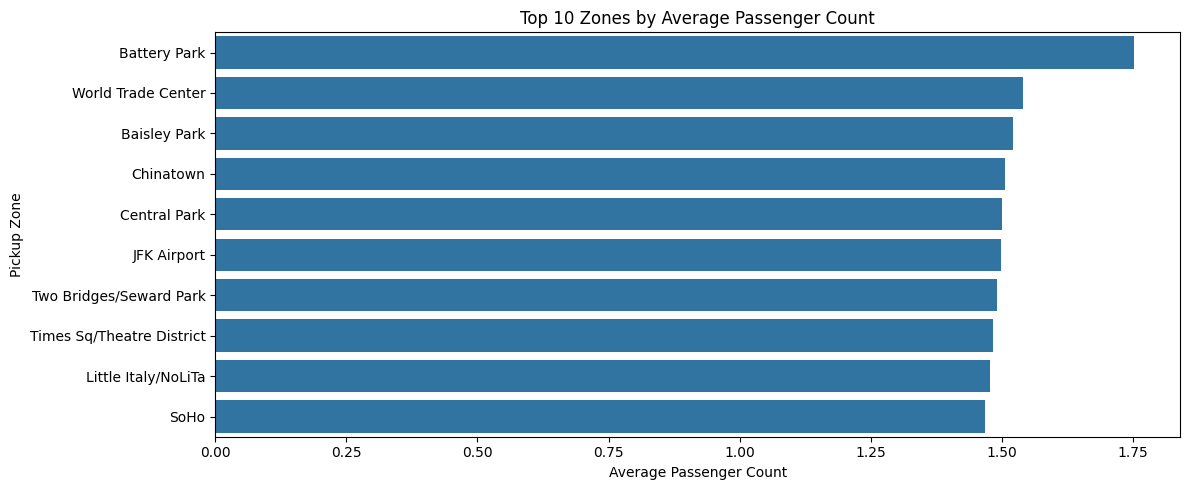

In [272]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=top_passenger_zones,
    x='avg_passenger_count',
    y='zone'
)

plt.title('Top 10 Zones by Average Passenger Count')
plt.xlabel('Average Passenger Count')
plt.ylabel('Pickup Zone')
plt.tight_layout()
plt.show()

In [273]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

zones_passenger_gdf = zones.copy()

zones_passenger_gdf = zones_passenger_gdf.drop(
    columns=['avg_passenger_count'],
    errors='ignore'
)

zones_passenger_gdf = zones_passenger_gdf.merge(
    zone_avg_passenger,
    on='LocationID',
    how='left'
)

zones_passenger_gdf['avg_passenger_count'] = zones_passenger_gdf['avg_passenger_count'].fillna(0)

zones_passenger_gdf.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,avg_passenger_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.666667
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",0.000000
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",2.000000
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",1.377593
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",0.000000


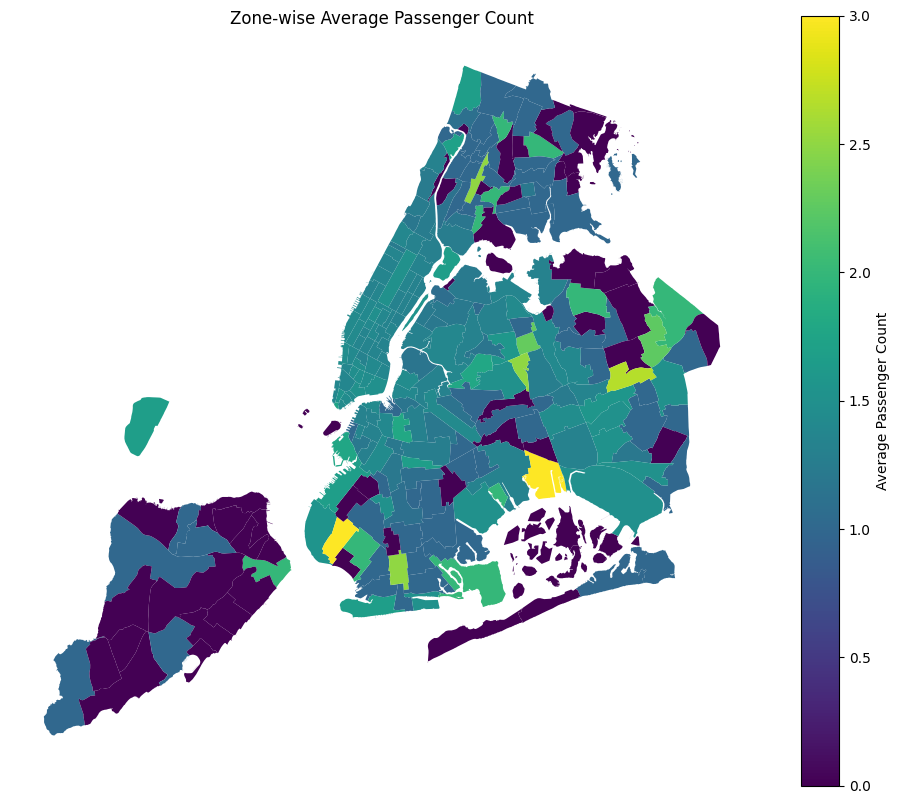

In [274]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

zones_passenger_gdf.plot(
    column='avg_passenger_count',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': 'Average Passenger Count',
        'orientation': 'vertical'
    }
)

ax.set_title('Zone-wise Average Passenger Count')
ax.set_axis_off()
plt.show()

In [275]:
highest_zone = top_passenger_zones.iloc[0]
lowest_zone = bottom_passenger_zones.iloc[0]

print(f"""
'{highest_zone['zone']}' has the highest average passenger count of {highest_zone['avg_passenger_count']:.2f}.

'{lowest_zone['zone']}' has the lowest average passenger count of {lowest_zone['avg_passenger_count']:.2f}.
""")


'Battery Park' has the highest average passenger count of 1.75.

'Manhattanville' has the lowest average passenger count of 1.19.



Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [276]:
# How often is each surcharge applied?

surcharge_cols = [
    'extra',
    'mta_tax',
    'improvement_surcharge',
    'congestion_surcharge',
    'airport_fee',
    'tolls_amount'
]

surcharge_cols = [col for col in surcharge_cols if col in df.columns]

surcharge_cols

['extra',
 'mta_tax',
 'improvement_surcharge',
 'congestion_surcharge',
 'airport_fee',
 'tolls_amount']

In [277]:
# Create surcharge prevalence summary

surcharge_summary_list = []

total_trips = df.shape[0]

for col in surcharge_cols:
    charged_trip_count = (df[col] > 0).sum()
    charged_trip_percentage = (charged_trip_count / total_trips) * 100
    avg_amount_when_charged = df.loc[df[col] > 0, col].mean()

    surcharge_summary_list.append({
        'surcharge_column': col,
        'charged_trip_count': charged_trip_count,
        'charged_trip_percentage': charged_trip_percentage,
        'avg_amount_when_charged': avg_amount_when_charged
    })

surcharge_summary_df = pd.DataFrame(surcharge_summary_list)

surcharge_summary_df = surcharge_summary_df.sort_values(
    'charged_trip_percentage',
    ascending=False
)

surcharge_summary_df

,surcharge_column,charged_trip_count,charged_trip_percentage,avg_amount_when_charged
2,improvement_surcharge,254931,99.969413,0.999690
1,mta_tax,252675,99.084738,0.500004
3,congestion_surcharge,236861,92.883388,2.500000
0,extra,158793,62.269567,2.643390
4,airport_fee,22595,8.860472,1.624043
5,tolls_amount,20453,8.020501,7.321614


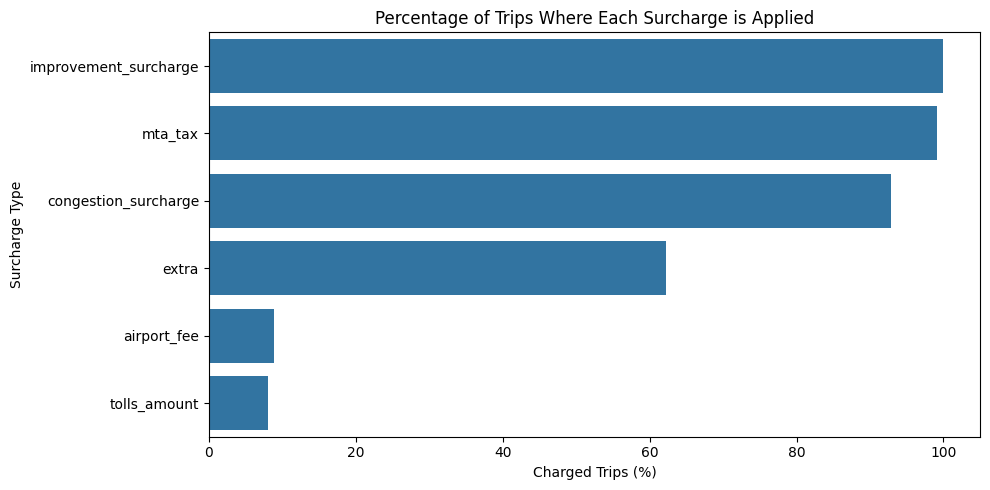

In [278]:
# Visualise how often each surcharge is applied

plt.figure(figsize=(10, 5))

sns.barplot(
    data=surcharge_summary_df,
    x='charged_trip_percentage',
    y='surcharge_column'
)

plt.title('Percentage of Trips Where Each Surcharge is Applied')
plt.xlabel('Charged Trips (%)')
plt.ylabel('Surcharge Type')
plt.tight_layout()
plt.show()

In [279]:
# Select meaningful operational extra-charge columns from surcharge_summary_df

operational_charge_cols = ['extra']

In [280]:
# Create one dataframe for extra-charge analysis by hour and zones

extra_charge_df = trip_zones[
    ['pickup_hour', 'pickup_zone', 'dropoff_zone'] + operational_charge_cols
].copy()

extra_charge_df['pickup_zone'] = extra_charge_df['pickup_zone'].fillna('Unknown Zone')
extra_charge_df['dropoff_zone'] = extra_charge_df['dropoff_zone'].fillna('Unknown Zone')

extra_charge_df.head()

,pickup_hour,pickup_zone,dropoff_zone,extra
0,0,Lincoln Square East,Lincoln Square East,1.0
1,0,JFK Airport,Midtown North,0.0
2,0,West Village,Ozone Park,1.0
3,0,Little Italy/NoLiTa,Two Bridges/Seward Park,1.0
4,0,East Village,Yorkville West,1.0


In [281]:
# Create total extra charge and has_extra_charge columns

extra_charge_df['total_extra_charges'] = extra_charge_df[operational_charge_cols].sum(axis=1)

extra_charge_df['has_extra_charge'] = extra_charge_df['total_extra_charges'] > 0

extra_charge_df.head()

,pickup_hour,pickup_zone,dropoff_zone,extra,total_extra_charges,has_extra_charge
0,0,Lincoln Square East,Lincoln Square East,1.0,1.0,True
1,0,JFK Airport,Midtown North,0.0,0.0,False
2,0,West Village,Ozone Park,1.0,1.0,True
3,0,Little Italy/NoLiTa,Two Bridges/Seward Park,1.0,1.0,True
4,0,East Village,Yorkville West,1.0,1.0,True


In [282]:
# Calculate extra-charge application rate by pickup hour

hourly_trip_count = (
    extra_charge_df
    .groupby('pickup_hour')
    .size()
    .reset_index(name='trip_count')
)

hourly_extra_charge_count = (
    extra_charge_df
    .groupby('pickup_hour')['has_extra_charge']
    .sum()
    .reset_index(name='extra_charge_trip_count')
)

hourly_extra_charge = hourly_trip_count.merge(
    hourly_extra_charge_count,
    on='pickup_hour',
    how='left'
)

hourly_extra_charge['extra_charge_rate_percentage'] = (
    hourly_extra_charge['extra_charge_trip_count'] / hourly_extra_charge['trip_count'] * 100
)

hourly_extra_charge

,pickup_hour,trip_count,extra_charge_trip_count,extra_charge_rate_percentage
0,0,7158,6856,95.780944
1,1,4789,4634,96.763416
2,2,3145,3063,97.392687
3,3,2045,1980,96.821516
4,4,1318,1207,91.578149
5,5,1315,1146,87.148289
6,6,3279,1066,32.509912
7,7,6755,2124,31.443375
8,8,9451,2877,30.441223
9,9,10821,3367,31.115424


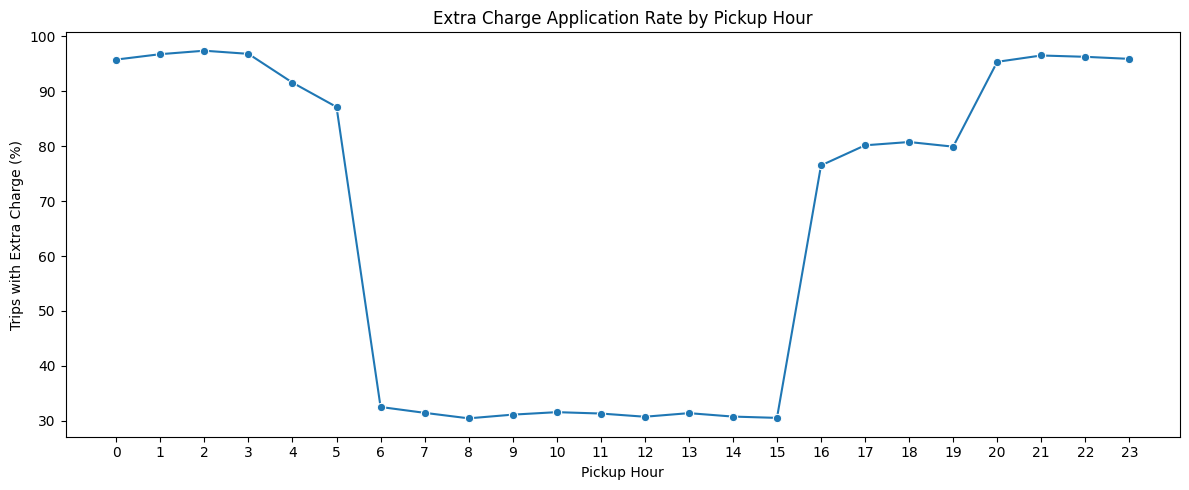

In [283]:
# Visualise extra-charge application rate by pickup hour

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_extra_charge,
    x='pickup_hour',
    y='extra_charge_rate_percentage',
    marker='o'
)

plt.title('Extra Charge Application Rate by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Trips with Extra Charge (%)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [284]:
# Calculate extra-charge application rate by pickup zone

pickup_zone_trip_count = (
    extra_charge_df
    .groupby('pickup_zone')
    .size()
    .reset_index(name='trip_count')
)

pickup_zone_extra_charge_count = (
    extra_charge_df
    .groupby('pickup_zone')['has_extra_charge']
    .sum()
    .reset_index(name='extra_charge_trip_count')
)

pickup_zone_extra_charge = pickup_zone_trip_count.merge(
    pickup_zone_extra_charge_count,
    on='pickup_zone',
    how='left'
)

pickup_zone_extra_charge['extra_charge_rate_percentage'] = (
    pickup_zone_extra_charge['extra_charge_trip_count'] / pickup_zone_extra_charge['trip_count'] * 100
)

pickup_zone_extra_charge = pickup_zone_extra_charge[
    pickup_zone_extra_charge['trip_count'] >= 50
].copy()

top_pickup_extra_charge_zones = (
    pickup_zone_extra_charge
    .sort_values('extra_charge_rate_percentage', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_pickup_extra_charge_zones

,pickup_zone,trip_count,extra_charge_trip_count,extra_charge_rate_percentage
0,LaGuardia Airport,8987,8884,98.853900
1,Williamsburg (North Side),65,58,89.230769
2,Lower East Side,2574,2157,83.799534
3,East Elmhurst,1181,986,83.488569
4,Alphabet City,241,196,81.327801
5,Greenwich Village South,3338,2662,79.748352
6,East Village,6039,4673,77.380361
7,West Village,5724,4347,75.943396
8,Little Italy/NoLiTa,2305,1694,73.492408
9,SoHo,1932,1357,70.238095


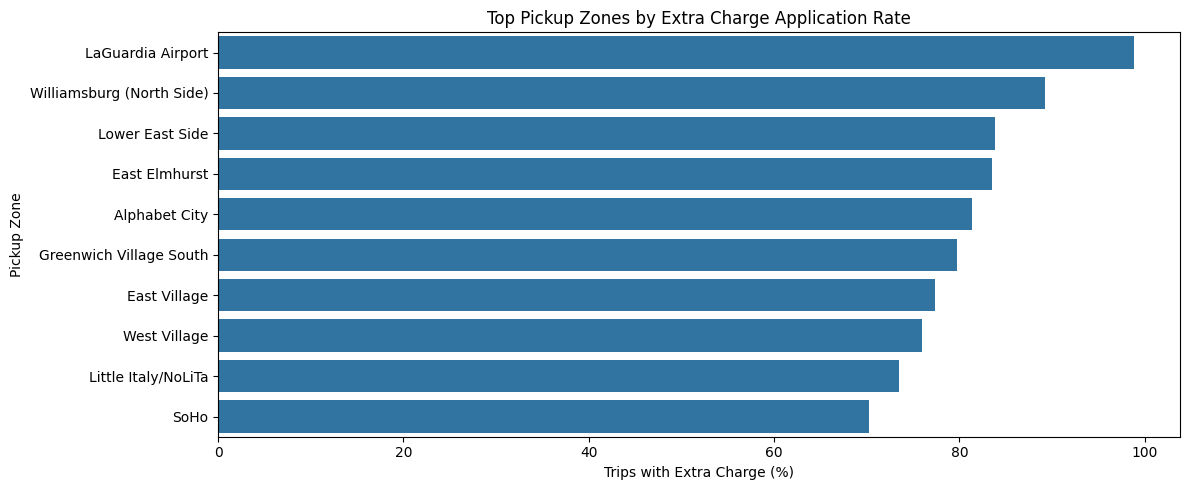

In [285]:
# Visualise top pickup zones by extra-charge application rate

plt.figure(figsize=(12, 5))

sns.barplot(
    data=top_pickup_extra_charge_zones,
    x='extra_charge_rate_percentage',
    y='pickup_zone'
)

plt.title('Top Pickup Zones by Extra Charge Application Rate')
plt.xlabel('Trips with Extra Charge (%)')
plt.ylabel('Pickup Zone')
plt.tight_layout()
plt.show()

In [286]:
# Calculate extra-charge application rate by dropoff zone

dropoff_zone_trip_count = (
    extra_charge_df
    .groupby('dropoff_zone')
    .size()
    .reset_index(name='trip_count')
)

dropoff_zone_extra_charge_count = (
    extra_charge_df
    .groupby('dropoff_zone')['has_extra_charge']
    .sum()
    .reset_index(name='extra_charge_trip_count')
)

dropoff_zone_extra_charge = dropoff_zone_trip_count.merge(
    dropoff_zone_extra_charge_count,
    on='dropoff_zone',
    how='left'
)

dropoff_zone_extra_charge['extra_charge_rate_percentage'] = (
    dropoff_zone_extra_charge['extra_charge_trip_count'] / dropoff_zone_extra_charge['trip_count'] * 100
)

dropoff_zone_extra_charge = dropoff_zone_extra_charge[
    dropoff_zone_extra_charge['trip_count'] >= 50
].copy()

top_dropoff_extra_charge_zones = (
    dropoff_zone_extra_charge
    .sort_values('extra_charge_rate_percentage', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_dropoff_extra_charge_zones

,dropoff_zone,trip_count,extra_charge_trip_count,extra_charge_rate_percentage
0,LaGuardia Airport,3089,3032,98.154743
1,Whitestone,54,47,87.037037
2,Cobble Hill,154,133,86.363636
3,Prospect Heights,206,174,84.466019
4,East Williamsburg,306,257,83.986928
5,Windsor Terrace,108,88,81.481481
6,Jamaica Estates,54,44,81.481481
7,Carroll Gardens,205,167,81.463415
8,Clinton Hill,342,278,81.286550
9,Boerum Hill,429,348,81.118881


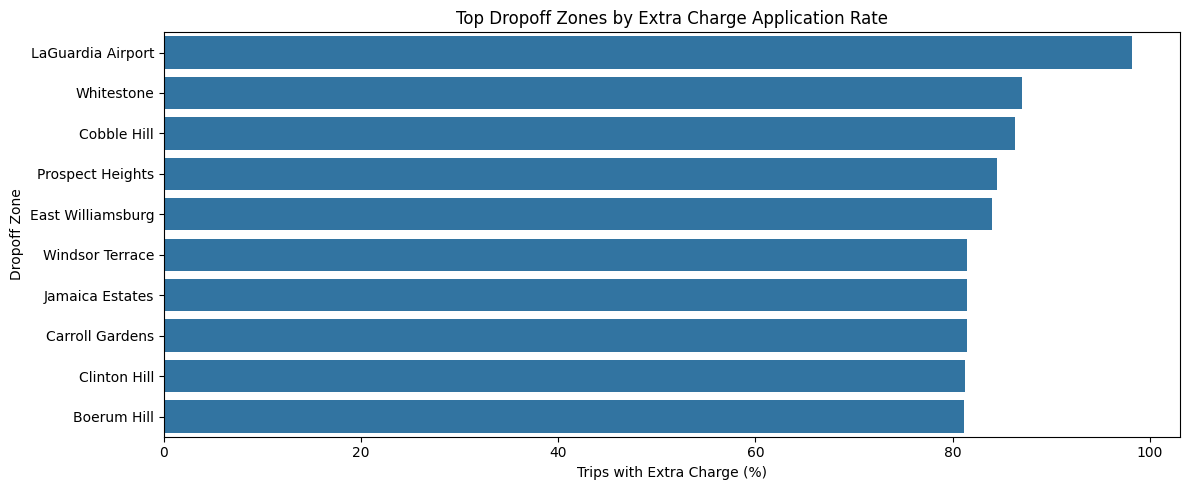

In [287]:
# Visualise top dropoff zones by extra-charge application rate

plt.figure(figsize=(12, 5))

sns.barplot(
    data=top_dropoff_extra_charge_zones,
    x='extra_charge_rate_percentage',
    y='dropoff_zone'
)

plt.title('Top Dropoff Zones by Extra Charge Application Rate')
plt.xlabel('Trips with Extra Charge (%)')
plt.ylabel('Dropoff Zone')
plt.tight_layout()
plt.show()

In [288]:
# Analysis Interpretation

top_surcharge = surcharge_summary_df.iloc[0]

top_hour = hourly_extra_charge.sort_values(
    'extra_charge_rate_percentage',
    ascending=False
).iloc[0]

top_pickup_zone = top_pickup_extra_charge_zones.iloc[0]
top_dropoff_zone = top_dropoff_extra_charge_zones.iloc[0]

print(f"""
{top_surcharge['surcharge_column']} is the most frequently applied surcharge, applied in {top_surcharge['charged_trip_percentage']:.2f}% of trips.

Extra charges are applied most frequently around {int(top_hour['pickup_hour'])}:00.

{top_pickup_zone['pickup_zone']} has the highest pickup-zone extra-charge rate, while {top_dropoff_zone['dropoff_zone']} has the highest dropoff-zone extra-charge rate.
""")


improvement_surcharge is the most frequently applied surcharge, applied in 99.97% of trips.

Extra charges are applied most frequently around 2:00.

LaGuardia Airport has the highest pickup-zone extra-charge rate, while LaGuardia Airport has the highest dropoff-zone extra-charge rate.



## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [289]:
print("""
 Evening time, especially around 18:00, shows high pickup activity, so more taxi should be available before and during this period.

 High pickup zones such as JFK Airport, Midtown area and other busy locations should be given more dispatch priority.
 For night hours, East Village should be considered important because it has high pickup and dropoff traffic between 11 PM and 5 AM.

 Slow Routes should also be monitored because they reduce the number of trips a trips a driver can complete in a day.
 If some routes are repeatedly slow during specific hours, drivers can be guided through alternate routes or nearby demand zones.

 Weekday and weekend demand should be planned separately. On weekdays, more taxis should be available around high-demand pickup zones
 identified in analysis. On weekends and late-night hours, supply should be shifted more toward nightlife and
 high night-traffic zones.

 Overall, routing and dispatching should be based on pickup hours, high demand zones, night traffic zones and slow route patterns.
""")


 Evening time, especially around 18:00, shows high pickup activity, so more taxi should be available before and during this period.

 High pickup zones such as JFK Airport, Midtown area and other busy locations should be given more dispatch priority.
 For night hours, East Village should be considered important because it has high pickup and dropoff traffic between 11 PM and 5 AM.

 Slow Routes should also be monitored because they reduce the number of trips a trips a driver can complete in a day.
 If some routes are repeatedly slow during specific hours, drivers can be guided through alternate routes or nearby demand zones.

 Weekday and weekend demand should be planned separately. On weekdays, more taxis should be available around high-demand pickup zones
 identified in analysis. On weekends and late-night hours, supply should be shifted more toward nightlife and
 high night-traffic zones.

 Overall, routing and dispatching should be based on pickup hours, high demand zones, night t

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [290]:
print("""
Based on the zone and time analysis, taxi positioning should not be random.
Taxis should be placed near the zones that showed high pickup demand, especially around peak hours.

Airport zones such as JFK Airport and LaGuardia Airport should have enough taxi supply because they appeared as busiest pickup zones.
and district like Midtown Center and other high pickup zones should also be covered during busy hours.

For late night hours, East Village should be given more attention because it had the highest night pickup and dropoff traffic.
This means some taxis should be positioned around such night-demand zones between 11 PM and 5 AM.

Dropoff-heavy zones should be also be used for repositioning. If many trips end in a zone but pickups are lower there,
drivers should not wait too long in that area and should be guided towards nearby pickup-heavy zones.

During months or days where trip demand is higher, taxi supply should be increased in these already busy zones.
Overall, taxi repositioning should depend on pickup zones, dropoff patterns, peak hours, night demand and monthly demand trends.
""")


Based on the zone and time analysis, taxi positioning should not be random.
Taxis should be placed near the zones that showed high pickup demand, especially around peak hours.

Airport zones such as JFK Airport and LaGuardia Airport should have enough taxi supply because they appeared as busiest pickup zones.
and district like Midtown Center and other high pickup zones should also be covered during busy hours.

For late night hours, East Village should be given more attention because it had the highest night pickup and dropoff traffic.
This means some taxis should be positioned around such night-demand zones between 11 PM and 5 AM.

Dropoff-heavy zones should be also be used for repositioning. If many trips end in a zone but pickups are lower there,
drivers should not wait too long in that area and should be guided towards nearby pickup-heavy zones.

During months or days where trip demand is higher, taxi supply should be increased in these already busy zones.
Overall, taxi reposition

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

In [291]:
print("""
Based on the pricing analysis, fare strategy should not be changed in one common way for all trips.
Fare per mile changes by distance, pickup hour, day of week so pricing decisions should be made using these patterns.

Short distance trips should be analysed separately from medim and long distance trips because fare per mile is usually different across distance tiers.
For trips upto 2 miles, 2 to 5 miles and more than 5 miles, vendor wise fare per mile should be compared before making pricing change.

Since daytime trips contribute and major part of total revenue, pricing strategy should be mainly protect daytime demand and avoid making fares too high
during already busy periods.For nighttime, where revenue share is lower or selected pricing adjustments can be used in high-demand night zones instead of increasing prices everywhere.

Passenger count analysis shows that fare per mile per passenger reduces when more passengers travel togather. so group rides can be promoted as better value for customers,
especially during high-demand hours.

Tip percentage should also be considered before changing prices. If some distance groups, passenger counts or pickup times already show low tip percentage, increasing charges
too much in those segments may affect customer experience.

Overall, pricing should be adjusted carefully by distance tier, pickup hour pattern instead of applying one common price change for all trips.
""")


Based on the pricing analysis, fare strategy should not be changed in one common way for all trips.
Fare per mile changes by distance, pickup hour, day of week so pricing decisions should be made using these patterns.

Short distance trips should be analysed separately from medim and long distance trips because fare per mile is usually different across distance tiers.
For trips upto 2 miles, 2 to 5 miles and more than 5 miles, vendor wise fare per mile should be compared before making pricing change.

Since daytime trips contribute and major part of total revenue, pricing strategy should be mainly protect daytime demand and avoid making fares too high
during already busy periods.For nighttime, where revenue share is lower or selected pricing adjustments can be used in high-demand night zones instead of increasing prices everywhere.

Passenger count analysis shows that fare per mile per passenger reduces when more passengers travel togather. so group rides can be promoted as better val